<section role="region" aria-labelledby="alchemi-notebook-title" style="position:relative;max-width:880px;aspect-ratio:2/1;margin:0 0 18px;overflow:hidden;border-radius:12px;background:#050607;border:1px solid #252A30;box-shadow:0 2px 8px rgba(0,0,0,0.18);font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><img src="assets/images/banner_candidates/water-ir-v2-04-trajectory-to-spectrum.png" alt="Two complete bent water molecules suspended in a dark computational field, linked by a hydrogen bond beside a green vibrational-signal motif" style="position:absolute;inset:0;width:100%;height:100%;object-fit:cover;display:block;"><div aria-hidden="true" style="position:absolute;inset:0;background:linear-gradient(90deg,rgba(3,5,6,0.98) 0%,rgba(3,5,6,0.91) 39%,rgba(3,5,6,0.18) 68%,rgba(3,5,6,0.03) 100%);"></div><div style="position:relative;z-index:1;width:55%;height:100%;box-sizing:border-box;padding:34px 30px;display:flex;flex-direction:column;justify-content:center;align-items:flex-start;"><div style="color:#B8C0C7;font-size:11px;font-weight:800;letter-spacing:0.12em;margin-bottom:10px;">NVIDIA ALCHEMI TOOLKIT</div><h1 id="alchemi-notebook-title" style="color:#FFFFFF;font-size:clamp(25px,4.1vw,42px);font-weight:500;line-height:1.10;letter-spacing:-0.02em;margin:0 0 13px;">From one water dimer to a batched IR trajectory</h1><p style="color:#D7DCE0;font-size:14px;line-height:1.45;margin:0 0 18px;max-width:430px;">Build the potential, prove the batch, and run the complete predicted-charge trajectory.</p><div style="display:inline-flex;align-items:center;gap:9px;background:#FFFFFF;color:#111827;border-radius:8px;padding:8px 11px;font-size:11px;font-weight:800;letter-spacing:0.06em;box-shadow:0 1px 2px rgba(0,0,0,0.22);"><span aria-hidden="true" style="display:inline-block;width:4px;height:18px;border-radius:999px;background:#76B900;"></span>PART 1 · LIVE GPU</div></div></section>

<dl aria-label="Lesson summary" style="max-width:880px;margin:14px 0;display:grid;grid-template-columns:repeat(auto-fit,minmax(220px,1fr));gap:10px;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="min-width:0;padding:12px 13px;background:#FFFFFF;border:1px solid #D1D5DB;border-top:3px solid #76B900;border-radius:10px;"><dt style="color:#4B5563;font-size:11px;font-weight:800;letter-spacing:0.09em;margin:0 0 5px;">DO</dt><dd style="color:#111827;font-size:13px;line-height:1.48;margin:0;">Evaluate one structure, prove serial-batch parity, measure CPU/GPU and layout performance, compose AIMNet2 + Coulomb + D3, then run one four-system IR calculation.</dd></div><div style="min-width:0;padding:12px 13px;background:#FFFFFF;border:1px solid #D1D5DB;border-top:3px solid #76B900;border-radius:10px;"><dt style="color:#4B5563;font-size:11px;font-weight:800;letter-spacing:0.09em;margin:0 0 5px;">LEARN</dt><dd style="color:#111827;font-size:13px;line-height:1.48;margin:0;">AtomicData, Batch, model configuration, neighbors, model composition, FIRE2, fused NVT to NVE, hooks, segmented reductions, and restartable artifacts.</dd></div><div style="min-width:0;padding:12px 13px;background:#FFFFFF;border:1px solid #D1D5DB;border-top:3px solid #76B900;border-radius:10px;"><dt style="color:#4B5563;font-size:11px;font-weight:800;letter-spacing:0.09em;margin:0 0 5px;">NEED</dt><dd style="color:#111827;font-size:13px;line-height:1.48;margin:0;">One CUDA GPU and the pinned ALCHEMI environment. Expect about 30-40 minutes on an H100; the 55,000-step path is never shortened for a weaker GPU.</dd></div></dl>

<aside role="note" aria-label="BOUNDARY" style="max-width:880px;margin:14px 0;padding:13px 16px;border:1px solid #9A3412;border-left-width:5px;border-radius:12px;background:#FFEDD5;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="color:#9A3412;font-size:12px;font-weight:800;letter-spacing:0.07em;margin-bottom:5px;">BOUNDARY</div><div style="color:#111827;font-size:14px;line-height:1.55;">Scientific scope: the final curves are normalized classical spectra from AIMNet2&#x27;s predicted-charge dipole. Absolute intensities are not benchmarked. Isotope and cluster shifts are reported only when the declared thermal and topology gates pass.</div></aside>

<aside role="note" aria-label="CHECK" style="max-width:880px;margin:14px 0;padding:13px 16px;border:1px solid #854D0E;border-left-width:5px;border-radius:12px;background:#FEF9C3;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="color:#854D0E;font-size:12px;font-weight:800;letter-spacing:0.07em;margin-bottom:5px;">CHECK</div><div style="color:#111827;font-size:14px;line-height:1.55;">Central question: can one composed potential evaluate many water structures without changing the physics, then reuse its predicted charges to produce an inspectable IR trajectory?</div></aside>


## Notebook map

1. First result — ASE → `AtomicData` → one model call.
2. Same physics, one batch — parity, CPU/GPU crossover, homogeneous vs heterogeneous layout.
3. Open the model — residual, finite-system all-pairs electrostatics, pairwise D3(BJ), and a full B97-3c endpoint.
4. Prepare IR — isotope batch, `segmented_sum`, FIRE2, hooks.
5. Full H100 run — 5,000 NVT + 50,000 NVE steps, with raw artifacts saved first.
6. Decide what survived — topology, thermal gates, spectra, harmonic mode mapping.


<aside role="note" aria-label="BOUNDARY" style="max-width:880px;margin:14px 0;padding:13px 16px;border:1px solid #9A3412;border-left-width:5px;border-radius:12px;background:#FFEDD5;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="color:#9A3412;font-size:12px;font-weight:800;letter-spacing:0.07em;margin-bottom:5px;">BOUNDARY</div><div style="color:#111827;font-size:14px;line-height:1.55;">The long trajectory is unconditional. Saved artifacts let you repeat analysis without pretending a partial trajectory is the result.</div></aside>


In [ ]:
from __future__ import annotations

import sys
from pathlib import Path

PART_NAME = "part-1-water-hydrogen-bonding-toolkit"
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
if (Path.cwd() / PART_NAME).is_dir():
    sys.path.insert(0, str(Path.cwd() / PART_NAME))

from aux.ui import NotebookProgress

setup_progress = NotebookProgress(
    title="Verify the pinned runtime", total=3, unit="checks"
)

import logging
import os
from importlib import metadata
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

# Compiler failures still raise; the external job transcript retains stderr.
torch._logging.set_logs(dynamo=logging.ERROR, inductor=logging.CRITICAL)
setup_progress.advance(message="Scientific Python and PyTorch imported")

from aux.runtime import find_bootcamp_root, verify_toolkit_pins

ROOT = find_bootcamp_root()
PART_DIR = ROOT / PART_NAME
RUN_ID = os.environ.get("ALCHEMI_RUN_ID", os.environ.get("SLURM_JOB_ID", "interactive"))
if not RUN_ID.replace("-", "").replace("_", "").isalnum():
    raise ValueError("ALCHEMI_RUN_ID may contain only letters, numbers, '-' and '_'")
OUTPUT_DIR = PART_DIR / "outputs" / f"run-{RUN_ID}"
REFERENCE_ROOT = PART_DIR / "reference" / "artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if str(PART_DIR) not in sys.path:
    sys.path.insert(0, str(PART_DIR))

CORE_COMMIT = "b770ee6963fd2f6137891e408c370012751918e2"
OPS_COMMIT = "c6fbe652315e0cebd4f57a6a25f626258f0dbbfd"
EXPECTED_AIMNET_VERSION = "0.2.0"
EXPECTED_TORCH_PREFIX = "2.12.0"
requirements = (ROOT / "build" / "requirements.txt").read_text()
assert CORE_COMMIT in requirements and OPS_COMMIT in requirements
installed_pins = verify_toolkit_pins(CORE_COMMIT, OPS_COMMIT)
assert metadata.version("aimnet") == EXPECTED_AIMNET_VERSION
assert torch.__version__.startswith(EXPECTED_TORCH_PREFIX)
setup_progress.advance(message="Toolkit commits and package versions verified")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type != "cuda":
    raise RuntimeError("The complete 55,000-step tutorial requires a CUDA GPU.")

DT_FS = 0.5
TEMPERATURE_K = 75.0
WARMUP_STEPS = 5_000
PRODUCTION_STEPS = 50_000
TOTAL_DYNAMICS_STEPS = WARMUP_STEPS + PRODUCTION_STEPS
FIRE_MAX_STEPS = 5_000
FIRE_FMAX_EV_A = 0.01
D3_CUTOFF_A = 15.0
NEIGHBOR_SKIN_A = 0.5
PAIR_TEMPERATURE_RELATIVE_TOLERANCE = 0.20
ENERGY_EXCURSION_ADVISORY_MEV_PER_ATOM = 1.0
OXYGEN_CONNECTIVITY_CUTOFF_A = 4.0
COVALENT_OH_CUTOFF_A = 1.25
HBOND_H_ACCEPTOR_CUTOFF_A = 2.5
HBOND_OO_CUTOFF_A = 3.5
HBOND_ANGLE_CUTOFF_DEG = 140.0
DIMER_DISTANCES_A = np.array([2.50, 2.70, 2.90, 3.20, 3.50, 3.90, 4.40, 5.00])
MODEL_CHECKPOINT = os.environ.get(
    "ALCHEMI_AIMNET_CHECKPOINT", "aimnet2-b973c-2025-d3_0"
)
D3_PARAMETER_FILE = Path(os.environ.get(
    "ALCHEMI_D3_PARAM_FILE",
    Path.home() / ".cache" / "nvalchemiops" / "dftd3_parameters.pt",
))
EXPECTED_D3_PARAMETER_SHA256 = (
    "b4828b87b63a43918769d467249492b53f7af94d2ab7ac5ac584a44aa399ec84"
)
setup_progress.complete("Pinned runtime and CUDA device verified")

print("GPU       :", torch.cuda.get_device_name(DEVICE))
print("checkpoint:", MODEL_CHECKPOINT)
print("trajectory:", f"{PRODUCTION_STEPS * DT_FS / 1000:.1f} ps NVE")
print("Core/Ops  :", installed_pins["Core"][:12], installed_pins["Ops"][:12])
print("AIMNet    :", metadata.version("aimnet"))
print("Torch     :", torch.__version__)


In [ ]:
imports_progress = NotebookProgress(
    title="Load simulation APIs", total=3, unit="groups"
)

from aimnet.calculators import AIMNet2Calculator
from ase import Atoms
from ase.io import write
from ase.visualize import view
imports_progress.advance(message="AIMNet and ASE imported")

# Public NVIDIA ALCHEMI Toolkit APIs used in the learning path.
from nvalchemi.data import AtomicData, Batch
from nvalchemi.dynamics import (
    ConvergenceHook,
    FIRE2,
    FusedStage,
    NVE,
    NVTLangevin,
    ZarrData,
    initialize_velocities,
)
from nvalchemi.dynamics.hooks import (
    LoggingHook,
    NaNDetectorHook,
)
from nvalchemi.hooks import Hook
from nvalchemi.models import (
    AIMNet2Wrapper,
    DFTD3ModelWrapper,
    PipelineGroup,
    PipelineModelWrapper,
)
from nvalchemi.neighbors import compute_neighbors
from nvalchemiops.torch import segmented_sum
imports_progress.advance(message="Public Toolkit APIs imported")

# Notebook-specific structures, recording, analysis, and presentation.
from aux.analysis import (
    dimer_interaction_energy_table,
    h_to_d_mode_mapping_table,
    ir_comparison_gate_table,
    ir_spectrum_metrics,
    reference_comparison_metrics,
    topology_time_series,
)
from aux.artifacts import (
    graph_atoms_from_batch,
    load_ir_trajectory,
    save_ir_trajectory,
    sha256_file,
    write_water_run_manifest,
    write_structure_artifacts,
)
from aux.benchmarking import (
    compare_fixed_workload_devices,
    compare_mixed_and_bucketed,
    first_and_warm_call_rows,
)
from aux.capture import PredictedChargeIRHook
from aux.checkpoint import checkpoint_card, resolve_checkpoint_path
from aux.diagnostics import cluster_integrity, mass_only_invariance
from aux.electrostatics import DirectCoulombWrapper
from aux.hooks import NotebookStageProgressHook
from aux.plotting import (
    plot_dimer_interaction_energies,
    plot_md_dft_comparison,
    plot_topology_timeline,
)
from aux.reference import load_psi4_b973c_ir_artifact
from aux.reference_data import load_verified_b97_3c_dimer_reference
from aux.structures import (
    make_ir_structures,
    make_water_dimer,
    make_water_dimer_scan,
    make_water_monomer,
)
from aux.ui import callout

imports_progress.complete("Toolkit APIs and focused auxiliary modules loaded")

display(callout("Public Toolkit imports and auxiliary mechanics loaded.", kind="result", result_state="pass"))


<section role="region" aria-labelledby="alchemi-stage-1-heading" style="max-width:880px;margin:18px 0;background:#FFFFFF;border:1px solid #D1D5DB;border-radius:12px;overflow:hidden;box-shadow:0 1px 2px rgba(0,0,0,0.05);font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div role="progressbar" aria-label="Notebook stage" aria-valuemin="1" aria-valuemax="6" aria-valuenow="1" aria-valuetext="STAGE 1 OF 6" style="height:6px;background:#E5E7EB;overflow:hidden;"><div aria-hidden="true" style="height:100%;width:16.67%;background:#76B900;"></div></div><div style="padding:16px 18px 17px;"><div style="display:flex;align-items:center;justify-content:space-between;gap:12px;flex-wrap:wrap;margin-bottom:9px;"><span style="color:#4B5563;font-size:12px;font-weight:700;letter-spacing:0.08em;">STAGE 1 OF 6</span><span style="display:inline-block;padding:3px 9px;border-radius:999px;background:#F3F4F6;color:#374151;font-size:12px;font-weight:750;letter-spacing:0.04em;">STAGE</span></div><h2 id="alchemi-stage-1-heading" style="color:#111827;font-size:21px;font-weight:750;line-height:1.25;margin:0 0 7px;">First result</h2><div style="color:#4B5563;font-size:14px;line-height:1.55;"><strong style="color:#111827;">Outcome:</strong> Turn one ASE water dimer into a residual interaction energy, forces, and predicted charges.</div></div></section>

<aside role="note" aria-label="BEFORE YOU RUN" style="max-width:880px;margin:14px 0;padding:13px 16px;border:1px solid #075985;border-left-width:5px;border-radius:12px;background:#E0F2FE;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="color:#075985;font-size:12px;font-weight:800;letter-spacing:0.07em;margin-bottom:5px;">BEFORE YOU RUN</div><div style="color:#111827;font-size:14px;line-height:1.55;">Before running: isotope substitution changes nuclear mass, not this potential-energy prediction.</div></aside>

- The generated geometry is an illustrative hydrogen-bonded scan seed, not an optimized reference.
- The first value is the checkpoint residual, including its embedded short-range Coulomb subtraction. Finite-system all-pairs Coulomb and D3 are restored in Stage 3.


### The atomistic simulation loop

1. **State:** elements, positions, masses, cell.
2. **Model:** potential energy $E(\mathbf R)$ and charges $q(\mathbf R)$.
3. **Autograd:** forces $\mathbf F=-\nabla_{\mathbf R}E$.
4. **Integrator:** update positions and velocities by one small time step; repeat.



<div role="img" aria-label="Illustration slot: The atomistic simulation loop. atoms → energy and charges → forces → time integration → updated atoms" style="max-width:880px;margin:14px 0;padding:22px 24px;border:1px dashed #9CA3AF;border-radius:12px;text-align:left;color:#4B5563;background:#F9FAFB;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="display:flex;align-items:center;gap:10px;margin-bottom:7px;"><span aria-hidden="true" style="display:inline-block;width:4px;height:22px;border-radius:999px;background:#76B900;"></span><strong style="color:#111827;font-size:14px;letter-spacing:0.02em;">The atomistic simulation loop</strong></div><div style="font-size:13px;line-height:1.5;">atoms → energy and charges → forces → time integration → updated atoms</div><div style="font-size:10px;font-weight:800;letter-spacing:0.10em;margin-top:9px;color:#6B7280;">ILLUSTRATION SLOT · VISUAL REVIEW</div></div>

<aside role="note" aria-label="BOUNDARY" style="max-width:880px;margin:14px 0;padding:13px 16px;border:1px solid #9A3412;border-left-width:5px;border-radius:12px;background:#FFEDD5;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="color:#9A3412;font-size:12px;font-weight:800;letter-spacing:0.07em;margin-bottom:5px;">BOUNDARY</div><div style="color:#111827;font-size:14px;line-height:1.55;">The potential supplies the landscape; the integrator supplies the trajectory. They are separate choices.</div></aside>


In [ ]:
water_dimer = make_water_dimer(oo_distance=2.90)
water_dimer.info["charge"] = 0

print(water_dimer)
print("O–O distance:", water_dimer.info["oo_distance_angstrom"], "Å")
display(view(water_dimer, viewer="x3d"))


In [ ]:
checkpoint_path = resolve_checkpoint_path(MODEL_CHECKPOINT)
checkpoint_progress = NotebookProgress(
    title="Load pinned AIMNet2 checkpoint", total=1, unit="checkpoint"
)
aimnet = AIMNet2Wrapper.from_checkpoint(checkpoint_path, device=DEVICE)
aimnet.eval()
for parameter in aimnet.parameters():
    parameter.requires_grad_(False)
aimnet.set_config("active_outputs", {"energy", "forces", "charges"})
model_card = checkpoint_card(aimnet, MODEL_CHECKPOINT, checkpoint_path)
EXPECTED_DEFAULT_CHECKPOINT_SHA256 = "043ed5418a104e31f79462f8e5ebeca64a2d24422174f5d29f894d32271981b5"
checkpoint_is_override = "ALCHEMI_AIMNET_CHECKPOINT" in os.environ
if not checkpoint_is_override:
    assert model_card["checkpoint_sha256"] == EXPECTED_DEFAULT_CHECKPOINT_SHA256
checkpoint_progress.complete("Checkpoint loaded and SHA-256 verified")

display(pd.Series({
    "checkpoint": model_card["checkpoint_source"],
    "checkpoint_sha256": model_card["checkpoint_sha256"],
    "target": "B97-3c-derived residual",
    "domain": "finite molecules; not a materials or adsorption potential",
    "implemented_atomic_numbers": model_card.get("implemented_species"),
    "weight_license": "MIT",
    "cutoff_A": aimnet.model_config.neighbor_config.cutoff,
    "external_coulomb": model_card["needs_coulomb"],
    "external_dispersion": model_card["needs_dispersion"],
    "supports_pbc": aimnet.model_config.supports_pbc,
    "optional_inputs": sorted(aimnet.model_config.optional_inputs),
    "neighbor_convention": str(aimnet.model_config.neighbor_config),
    "device": str(DEVICE),
    "dtype_boundary": "Toolkit float64 coordinates; AIMNet internal float32",
}, name="model card").to_frame())
print("outputs        :", sorted(aimnet.model_config.outputs))
print("active outputs :", sorted(aimnet.model_config.active_outputs))
print("required inputs:", sorted(aimnet.model_config.required_inputs))
print("neighbors      :", aimnet.model_config.neighbor_config)
if checkpoint_is_override:
    display(callout(
        "ALCHEMI_AIMNET_CHECKPOINT overrides the validated member-0 bytes. This run is labeled unvalidated until its own reference checks pass.",
        kind="boundary",
    ))


In [ ]:
first_prediction_progress = NotebookProgress(
    title="Evaluate the first water interaction", total=1, unit="model call"
)
dimer_fragments = [water_dimer, water_dimer[:3], water_dimer[3:]]
for atoms in dimer_fragments:
    atoms.info["charge"] = 0
dimer_data = [
    AtomicData.from_atoms(atoms, device=DEVICE, dtype=torch.float64)
    for atoms in dimer_fragments
]
single_batch = Batch.from_data_list(dimer_data, device=DEVICE)
compute_neighbors(single_batch, config=aimnet.model_config.neighbor_config)
first_outputs = aimnet(single_batch)

first_energy = first_outputs["energy"].detach().reshape(-1)
residual_interaction_kJ_mol = float(
    (first_energy[0] - first_energy[1] - first_energy[2]).cpu()
) * 96.48533212331002
charge_sums = segmented_sum(
    first_outputs["charges"].reshape(-1),
    single_batch.batch_idx.to(torch.int32),
    single_batch.num_graphs,
)
first_force_max = float(
    torch.linalg.vector_norm(first_outputs["forces"][:6], dim=1).max().detach().cpu()
)
first_prediction_progress.complete("Residual energy, forces, and charges evaluated")
display(pd.Series({
    "graphs": single_batch.num_graphs,
    "atoms": single_batch.num_nodes,
    "residual_interaction_kJ_mol": residual_interaction_kJ_mol,
    "dimer_max_force_eV_A": first_force_max,
    "max_abs_graph_charge_e": float(charge_sums.abs().max().detach().cpu()),
}, name="first model call").to_frame())
display(callout(
    f"Observed checkpoint-residual interaction: {residual_interaction_kJ_mol:.2f} kJ/mol. It includes the embedded short-range Coulomb subtraction and remains incomplete until finite-system all-pairs Coulomb and D3 are restored.",
    kind="result",
    result_state="observed",
))


<section role="region" aria-labelledby="alchemi-stage-2-heading" style="max-width:880px;margin:18px 0;background:#FFFFFF;border:1px solid #D1D5DB;border-radius:12px;overflow:hidden;box-shadow:0 1px 2px rgba(0,0,0,0.05);font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div role="progressbar" aria-label="Notebook stage" aria-valuemin="1" aria-valuemax="6" aria-valuenow="2" aria-valuetext="STAGE 2 OF 6" style="height:6px;background:#E5E7EB;overflow:hidden;"><div aria-hidden="true" style="height:100%;width:33.33%;background:#76B900;"></div></div><div style="padding:16px 18px 17px;"><div style="display:flex;align-items:center;justify-content:space-between;gap:12px;flex-wrap:wrap;margin-bottom:9px;"><span style="color:#4B5563;font-size:12px;font-weight:700;letter-spacing:0.08em;">STAGE 2 OF 6</span><span style="display:inline-block;padding:3px 9px;border-radius:999px;background:#F3F4F6;color:#374151;font-size:12px;font-weight:750;letter-spacing:0.04em;">STAGE</span></div><h2 id="alchemi-stage-2-heading" style="color:#111827;font-size:21px;font-weight:750;line-height:1.25;margin:0 0 7px;">Same physics, one batch</h2><div style="color:#4B5563;font-size:14px;line-height:1.55;"><strong style="color:#111827;">Outcome:</strong> Prove batching preserves every energy, then measure when GPU and batch layout help.</div></div></section>

<aside role="note" aria-label="BEFORE YOU RUN" style="max-width:880px;margin:14px 0;padding:13px 16px;border:1px solid #075985;border-left-width:5px;border-radius:12px;background:#E0F2FE;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="color:#075985;font-size:12px;font-weight:800;letter-spacing:0.07em;margin-bottom:5px;">BEFORE YOU RUN</div><div style="color:#111827;font-size:14px;line-height:1.55;">Predict the shape of batch_idx and batch_ptr for eight AB/A/B triplets before inspecting them.</div></aside>

- **Serial:** one graph and one model call at a time.
- **Batched:** the same graphs and model, one call.
- **Homogeneous:** similar graph sizes. **Heterogeneous:** mixed graph sizes; one mixed call can trade call overhead for padding/shape inefficiency.

- CPU wins when launch and transfer overhead dominate a small workload.
- GPU wins when many atoms, edges, or graphs keep its parallel lanes occupied.
- Batching increases useful work per launch; mixed graph sizes can reduce that efficiency.
- The crossover below times warm model calls only. Checkpoint loading, batch construction, host→device placement, and neighbor construction are deliberately outside the timed region.


<div role="img" aria-label="Illustration slot: CPU latency and GPU throughput. few latency-optimized CPU cores ↔ many throughput-optimized GPU lanes" style="max-width:880px;margin:14px 0;padding:22px 24px;border:1px dashed #9CA3AF;border-radius:12px;text-align:left;color:#4B5563;background:#F9FAFB;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="display:flex;align-items:center;gap:10px;margin-bottom:7px;"><span aria-hidden="true" style="display:inline-block;width:4px;height:22px;border-radius:999px;background:#76B900;"></span><strong style="color:#111827;font-size:14px;letter-spacing:0.02em;">CPU latency and GPU throughput</strong></div><div style="font-size:13px;line-height:1.5;">few latency-optimized CPU cores ↔ many throughput-optimized GPU lanes</div><div style="font-size:10px;font-weight:800;letter-spacing:0.10em;margin-top:9px;color:#6B7280;">ILLUSTRATION SLOT · VISUAL REVIEW</div></div>


In [ ]:
scan_dimers = make_water_dimer_scan(DIMER_DISTANCES_A)
scan_atoms = []
scan_roles = []
for dimer in scan_dimers:
    fragments = (dimer, dimer[:3], dimer[3:])
    for role, atoms in zip(("AB", "A", "B"), fragments, strict=True):
        atoms = atoms.copy()
        atoms.set_pbc(False)
        atoms.info["charge"] = 0
        scan_atoms.append(atoms)
        scan_roles.append(role)

scan_data = [
    AtomicData.from_atoms(atoms, device=DEVICE, dtype=torch.float64)
    for atoms in scan_atoms
]
print("structures:", len(scan_data), "=", len(DIMER_DISTANCES_A), "× (AB, A, B)")


In [ ]:
aimnet.set_config("active_outputs", {"energy", "charges"})

serial_batch_progress = NotebookProgress(
    title="Serial loop vs one Toolkit batch",
    total=len(scan_data) + 1,
    unit="model calls",
)
serial_energy = []
for serial_index, data in enumerate(scan_data, start=1):
    one_graph = Batch.from_data_list([data], device=DEVICE)
    compute_neighbors(one_graph, config=aimnet.model_config.neighbor_config)
    serial_energy.append(aimnet(one_graph)["energy"].detach().reshape(()))
    serial_batch_progress.update(
        done=serial_index,
        message=f"serial graph {serial_index} of {len(scan_data)}",
    )
serial_energy = torch.stack(serial_energy)

scan_batch = Batch.from_data_list(scan_data, device=DEVICE)
compute_neighbors(scan_batch, config=aimnet.model_config.neighbor_config)
batch_outputs = aimnet(scan_batch)
batch_energy = batch_outputs["energy"].detach().reshape(-1)
serial_batch_progress.complete("Serial loop and one batched call complete")

serial_batch_error = float(torch.max(torch.abs(serial_energy - batch_energy)).cpu())
assert serial_batch_error < 1e-5
residual_triplets = batch_energy.cpu().numpy().reshape(-1, 3)
residual_interaction_eV = (
    residual_triplets[:, 0] - residual_triplets[:, 1] - residual_triplets[:, 2]
)

display(pd.Series({
    "num_graphs": scan_batch.num_graphs,
    "num_atoms": scan_batch.num_nodes,
    "batch_idx_shape": tuple(scan_batch.batch_idx.shape),
    "batch_ptr": scan_batch.batch_ptr.cpu().tolist(),
    "max_abs_serial_minus_batch_eV": serial_batch_error,
}, name="batch contract").to_frame())

# Three public ways to move back from a batch to graph-level data.
first_graph = scan_batch.get_data(0)
roundtrip_graphs = scan_batch.to_data_list()
dimer_only_batch = scan_batch.index_select(list(range(0, scan_batch.num_graphs, 3)))
assert first_graph.num_nodes == 6
assert len(roundtrip_graphs) == scan_batch.num_graphs
assert dimer_only_batch.num_graphs == len(DIMER_DISTANCES_A)
print("get_data(0) atoms :", first_graph.num_nodes)
print("to_data_list size :", len(roundtrip_graphs))
print("index_select dimers:", dimer_only_batch.num_graphs)
display(callout("Serial and batched residual energies agree within 1e-5 eV.", kind="result", result_state="pass"))


In [ ]:
benchmark_progress = NotebookProgress(
    title="CPU / GPU fixed-workload sweep", total=6, unit="checks"
)

# Fresh wrappers make the first-call row distinct from the warm-call block.
del aimnet
torch.cuda.empty_cache()
aimnet = AIMNet2Wrapper.from_checkpoint(checkpoint_path, device=DEVICE)
cpu_aimnet = AIMNet2Wrapper.from_checkpoint(checkpoint_path, device="cpu")
for route_model in (aimnet, cpu_aimnet):
    route_model.eval()
    for parameter in route_model.parameters():
        parameter.requires_grad_(False)
    route_model.set_config("active_outputs", {"energy"})
benchmark_progress.advance(message="Fresh CPU and GPU wrappers loaded")

# First versus warm calls on one fixed 32-dimer workload.
timing_atoms = [make_water_dimer(2.90) for _ in range(32)]
for atoms in timing_atoms:
    atoms.info["charge"] = 0
gpu_timing_batch = Batch.from_data_list([
    AtomicData.from_atoms(atoms, device=DEVICE, dtype=torch.float64)
    for atoms in timing_atoms
], device=DEVICE)
cpu_timing_batch = Batch.from_data_list([
    AtomicData.from_atoms(atoms, device="cpu", dtype=torch.float64)
    for atoms in timing_atoms
], device="cpu")
compute_neighbors(gpu_timing_batch, config=aimnet.model_config.neighbor_config)
compute_neighbors(cpu_timing_batch, config=cpu_aimnet.model_config.neighbor_config)
cold_warm = pd.DataFrame(
    first_and_warm_call_rows(aimnet, gpu_timing_batch, warm_calls=20, route="GPU")
    + first_and_warm_call_rows(cpu_aimnet, cpu_timing_batch, warm_calls=20, route="CPU")
)
benchmark_progress.advance(message="First and warm 32-graph calls measured")
display(cold_warm[[
    "route", "phase", "calls", "wall_ms_per_pass", "structures_per_s"
]].round(2))

# Same structures, coordinates, neighbors, and number of timed calls.
benchmark_rows = []
for sweep_index, batch_size in enumerate((1, 8, 32, 128), start=1):
    atoms_set = [make_water_dimer(2.90) for _ in range(batch_size)]
    for atoms in atoms_set:
        atoms.info["charge"] = 0
    gpu_batch = Batch.from_data_list([
        AtomicData.from_atoms(atoms, device=DEVICE, dtype=torch.float64)
        for atoms in atoms_set
    ], device=DEVICE)
    cpu_batch = Batch.from_data_list([
        AtomicData.from_atoms(atoms, device="cpu", dtype=torch.float64)
        for atoms in atoms_set
    ], device="cpu")
    compute_neighbors(gpu_batch, config=aimnet.model_config.neighbor_config)
    compute_neighbors(cpu_batch, config=cpu_aimnet.model_config.neighbor_config)

    gpu_check = aimnet(gpu_batch)["energy"].detach().cpu().reshape(-1)
    cpu_check = cpu_aimnet(cpu_batch)["energy"].detach().cpu().reshape(-1)
    cpu_gpu_error = float(torch.max(torch.abs(gpu_check - cpu_check)))
    assert cpu_gpu_error < 2e-4
    rows = compare_fixed_workload_devices(
        {"GPU": (aimnet, gpu_batch), "CPU": (cpu_aimnet, cpu_batch)},
        warmup_calls=2,
        measured_calls=20,
    )
    for row in rows:
        row["batch_size"] = batch_size
        row["cpu_gpu_max_abs_energy_ueV"] = cpu_gpu_error * 1e6
    benchmark_rows.extend(rows)
    benchmark_progress.update(
        done=2 + sweep_index,
        message=f"batch size {batch_size}: CPU and GPU measured",
    )

crossover = pd.DataFrame(benchmark_rows)
benchmark_progress.complete("Four matched batch sizes complete")
display(crossover.sort_values(["batch_size", "route"])[[
    "batch_size", "route", "calls", "wall_ms_per_pass", "structures_per_s",
    "atoms_per_s", "cpu_gpu_max_abs_energy_ueV",
]].round(2))
display(callout(
    "Small batches are latency-bound; larger batches expose GPU parallelism. This is a synchronized warm-inference crossover, not end-to-end application latency.",
    kind="result",
    result_state="observed",
))
del cpu_aimnet, cpu_batch, gpu_batch, cpu_timing_batch, gpu_timing_batch


In [ ]:
# Fixed heterogeneous workload: 24 monomers, 12 dimers, 4 hexamers (216 atoms).
layout_progress = NotebookProgress(
    title="Homogeneous buckets vs one heterogeneous batch",
    total=1,
    unit="fixed-workload comparison",
)
layout_groups = [
    [make_water_monomer() for _ in range(24)],
    [make_water_dimer(2.90) for _ in range(12)],
    [make_ir_structures()[0][2].copy() for _ in range(4)],
]
for atoms in sum(layout_groups, []):
    atoms.info["charge"] = 0

mixed_atoms = sum(layout_groups, [])
mixed_batch = Batch.from_data_list([
    AtomicData.from_atoms(atoms, device=DEVICE, dtype=torch.float64)
    for atoms in mixed_atoms
], device=DEVICE)
bucket_batches = [
    Batch.from_data_list([
        AtomicData.from_atoms(atoms, device=DEVICE, dtype=torch.float64)
        for atoms in group
    ], device=DEVICE)
    for group in layout_groups
]
bucket_graph_indices = [
    np.arange(0, 24),
    np.arange(24, 36),
    np.arange(36, 40),
]
for route_batch in (mixed_batch, *bucket_batches):
    compute_neighbors(route_batch, config=aimnet.model_config.neighbor_config)

neighbor_storage = []
for route, route_batches in (
    ("one heterogeneous batch", [mixed_batch]),
    ("homogeneous buckets", bucket_batches),
):
    valid_slots = sum(int(item.num_neighbors.sum().cpu()) for item in route_batches)
    allocated_slots = sum(int(item.neighbor_matrix.numel()) for item in route_batches)
    neighbor_storage.append({
        "route": route,
        "valid_neighbor_slots": valid_slots,
        "allocated_neighbor_slots": allocated_slots,
        "neighbor_slot_utilization": valid_slots / allocated_slots,
    })

layout_result = compare_mixed_and_bucketed(
    aimnet,
    mixed_batch,
    bucket_batches,
    bucket_graph_indices,
    warmup_passes=2,
    measured_passes=20,
    atol=1e-5,
    rtol=0.0,
)
layout_progress.complete("Both layouts measured over 20 passes")
display(pd.DataFrame(layout_result["timings"])[[
    "route", "calls_per_pass", "graphs", "atoms", "wall_ms_per_pass", "structures_per_s"
]].round(2))
display(pd.DataFrame(neighbor_storage).round(3))
display(callout(
    f"Both layouts return the same energies (max |Δ| = {layout_result['max_abs_energy_difference']:.2e} eV). Which layout wins is empirical.",
    kind="result",
    result_state="pass",
))


<section role="region" aria-labelledby="alchemi-stage-3-heading" style="max-width:880px;margin:18px 0;background:#FFFFFF;border:1px solid #D1D5DB;border-radius:12px;overflow:hidden;box-shadow:0 1px 2px rgba(0,0,0,0.05);font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div role="progressbar" aria-label="Notebook stage" aria-valuemin="1" aria-valuemax="6" aria-valuenow="3" aria-valuetext="STAGE 3 OF 6" style="height:6px;background:#E5E7EB;overflow:hidden;"><div aria-hidden="true" style="height:100%;width:50.00%;background:#76B900;"></div></div><div style="padding:16px 18px 17px;"><div style="display:flex;align-items:center;justify-content:space-between;gap:12px;flex-wrap:wrap;margin-bottom:9px;"><span style="color:#4B5563;font-size:12px;font-weight:700;letter-spacing:0.08em;">STAGE 3 OF 6</span><span style="display:inline-block;padding:3px 9px;border-radius:999px;background:#F3F4F6;color:#374151;font-size:12px;font-weight:750;letter-spacing:0.04em;">STAGE</span></div><h2 id="alchemi-stage-3-heading" style="color:#111827;font-size:21px;font-weight:750;line-height:1.25;margin:0 0 7px;">Open the model</h2><div style="color:#4B5563;font-size:14px;line-height:1.55;"><strong style="color:#111827;">Outcome:</strong> Restore the checkpoint-declared electrostatics and dispersion, then compare the complete endpoint with B97-3c.</div></div></section>

<aside role="note" aria-label="BEFORE YOU RUN" style="max-width:880px;margin:14px 0;padding:13px 16px;border:1px solid #075985;border-left-width:5px;border-radius:12px;background:#E0F2FE;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="color:#075985;font-size:12px;font-weight:800;letter-spacing:0.07em;margin-bottom:5px;">BEFORE YOU RUN</div><div style="color:#111827;font-size:14px;line-height:1.55;">For a hydrogen-bonded dimer, predict whether omitting explicit electrostatics or omitting pairwise D3 changes the curve more.</div></aside>

The checkpoint residual has a short-range Coulomb subtraction embedded. We restore its intended finite-molecule convention with predicted-charge **all-pairs 1/r Coulomb** and add the published **pairwise D3(BJ)** term.

This is the official AIMNet calculator's default `simple` electrostatics for small nonperiodic molecules: no spatial cutoff and no periodic images. DSF is a scalable finite-cutoff alternative; Ewald and PME require a periodic cell. None is substituted into this vacuum-cluster endpoint. The DFT curve is a complete endpoint—not a term-by-term Coulomb match.


In [ ]:
# Variable-size scans remain eager. Compilation is reserved for the fixed IR
# workload in Stage 4, where its exact energy, charge, and force outputs are
# compared with this model before dynamics.
aimnet.set_config("active_outputs", {"energy", "charges"})

d3_params = model_card["d3_params"]
if not D3_PARAMETER_FILE.is_file():
    raise FileNotFoundError(
        "Pinned Toolkit D3 parameter cache is missing: "
        f"{D3_PARAMETER_FILE}. Prewarm it during environment setup; "
        "the tutorial does not download scientific data during execution."
    )
D3_PARAMETER_SHA256 = sha256_file(D3_PARAMETER_FILE)
assert D3_PARAMETER_SHA256 == EXPECTED_D3_PARAMETER_SHA256
coulomb = DirectCoulombWrapper().to(DEVICE)
d3 = DFTD3ModelWrapper(
    a1=d3_params["a1"],
    a2=d3_params["a2"],
    s8=d3_params["s8"],
    s6=d3_params.get("s6", 1.0),
    cutoff=D3_CUTOFF_A,
    param_file=D3_PARAMETER_FILE,
    auto_download=False,
).to(DEVICE)
for component in (aimnet, coulomb, d3):
    neighbor_config = component.model_config.neighbor_config
    if neighbor_config is not None:
        neighbor_config.skin = NEIGHBOR_SKIN_A

display(pd.DataFrame([
    {"component": "AIMNet residual", "depends_on": "positions, elements, total charge", "cutoff_A": aimnet.model_config.neighbor_config.cutoff},
    {"component": "finite all-pairs Coulomb", "depends_on": "AIMNet predicted charges", "cutoff_A": None},
    {"component": "pairwise D3(BJ)", "depends_on": "positions, elements", "cutoff_A": D3_CUTOFF_A},
]))
print("D3 parameter SHA-256:", D3_PARAMETER_SHA256)
print("D3 parameter file    :", D3_PARAMETER_FILE)


In [ ]:
component_progress = NotebookProgress(
    title="Evaluate model components", total=4, unit="passes"
)

compute_neighbors(scan_batch, config=aimnet.model_config.neighbor_config)
residual_outputs = aimnet(scan_batch)
residual_energy = residual_outputs["energy"].detach().reshape(-1)
scan_batch.charges = residual_outputs["charges"]
component_progress.update(done=1, message="AIMNet residual + charges")

coulomb.set_config("active_outputs", {"energy"})
coulomb_energy = coulomb(scan_batch)["energy"].detach().reshape(-1)
component_progress.update(done=2, message="finite all-pairs Coulomb")

d3.set_config("active_outputs", {"energy"})
compute_neighbors(scan_batch, config=d3.model_config.neighbor_config)
d3_energy = d3(scan_batch)["energy"].detach().reshape(-1)
component_progress.update(done=3, message="pairwise D3(BJ)")

# Pipeline construction snapshots each component's derivative contract.
# Restore force-producing outputs before the groups are assembled.
aimnet.set_config("active_outputs", {"energy", "charges"})
d3.set_config("active_outputs", {"energy", "forces"})
assert coulomb.direct_derivative_keys() == set()
assert "forces" in d3.model_config.active_outputs
model = PipelineModelWrapper(
    groups=[
        PipelineGroup(steps=[aimnet, coulomb], use_autograd=True),
        PipelineGroup(steps=[d3], use_autograd=False),
    ],
    neighbor_adaptation="always",
).to(DEVICE)
model.set_config("active_outputs", {"energy", "forces", "charges"})
model.eval()
for parameter in model.parameters():
    parameter.requires_grad_(False)

compute_neighbors(scan_batch, config=model.model_config.neighbor_config)
full_outputs = model(scan_batch)
full_energy = full_outputs["energy"].detach().reshape(-1)
component_sum = residual_energy + coulomb_energy + d3_energy
component_closure_error = float(torch.max(torch.abs(full_energy - component_sum)).cpu())
assert component_closure_error < 2e-5
assert torch.isfinite(full_outputs["forces"]).all()
assert float(torch.linalg.vector_norm(full_outputs["forces"], dim=1).max().cpu()) > 0.0
component_progress.complete("Pipeline equals the independently evaluated component sum")

print("pipeline groups:", [
    {"steps": [type(step.model).__name__ for step in group.steps], "use_autograd": group.use_autograd}
    for group in model.groups
])
print("active outputs:", sorted(model.model_config.active_outputs))
print("neighbors     :", model.model_config.neighbor_config)
print("energy component closure / eV:", f"{component_closure_error:.3e}")


In [ ]:
parity_progress = NotebookProgress(
    title="Composition parity and force gate", total=5, unit="checks"
)
official = AIMNet2Calculator(
    str(checkpoint_path),
    device=str(DEVICE),
    needs_coulomb=True,
    needs_dispersion=True,
    compile_model=False,
    train=False,
)
official.set_lrcoulomb_method("simple")
official.set_dftd3_cutoff(cutoff=D3_CUTOFF_A, smoothing_fraction=0.2)
parity_progress.update(done=1, message="official AIMNet all-pairs Coulomb + D3 configured")

official_outputs = official({
    "coord": scan_batch.positions.detach().clone(),
    "numbers": scan_batch.atomic_numbers.detach().clone(),
    "charge": scan_batch.charge.detach().reshape(-1).clone(),
    "mol_idx": scan_batch.batch_idx.detach().clone(),
}, forces=True)
parity_progress.update(done=2, message="official calculator evaluated")

parity_errors = {
    "energy_eV": float(torch.max(torch.abs(
        full_outputs["energy"].reshape(-1) - official_outputs["energy"].reshape(-1)
    )).detach().cpu()),
    "forces_eV_A": float(torch.max(torch.abs(
        full_outputs["forces"] - official_outputs["forces"]
    )).detach().cpu()),
    "charges_e": float(torch.max(torch.abs(
        full_outputs["charges"].reshape(-1) - official_outputs["charges"].reshape(-1)
    )).detach().cpu()),
}
assert parity_errors["energy_eV"] < 3e-6
assert parity_errors["forces_eV_A"] < 2e-6
assert parity_errors["charges_e"] < 1e-7
parity_progress.update(done=3, message="Toolkit pipeline matches official calculator")

# A two-charge system makes the 1/2 ordered-pair convention, sign, and force
# direction independently checkable without invoking AIMNet or D3.
two_charge_distance_A = 2.0
two_charge_values_e = torch.tensor([0.75, -0.75], device=DEVICE)
two_charge_atoms = Atoms(
    "H2", positions=[[0.0, 0.0, 0.0], [two_charge_distance_A, 0.0, 0.0]]
)
two_charge_atoms.info["charge"] = 0
two_charge_data = AtomicData.from_atoms(
    two_charge_atoms, device=DEVICE, dtype=torch.float64
)
two_charge_batch = Batch.from_data_list([two_charge_data], device=DEVICE)
two_charge_batch.charges = two_charge_values_e
two_charge_batch.positions.requires_grad_(True)
two_charge_energy_tensor = coulomb(two_charge_batch)["energy"].sum()
two_charge_forces = -torch.autograd.grad(
    two_charge_energy_tensor, two_charge_batch.positions
)[0]
two_charge_expected_energy_eV = (
    coulomb.coulomb_constant
    * float(torch.prod(two_charge_values_e).cpu())
    / two_charge_distance_A
)
two_charge_expected_force_eV_A = (
    coulomb.coulomb_constant
    * abs(float(torch.prod(two_charge_values_e).cpu()))
    / two_charge_distance_A**2
)
analytic_coulomb_errors = {
    "energy_eV": abs(
        float(two_charge_energy_tensor.detach().cpu())
        - two_charge_expected_energy_eV
    ),
    "forces_eV_A": float(torch.max(torch.abs(
        two_charge_forces
        - torch.tensor(
            [
                [two_charge_expected_force_eV_A, 0.0, 0.0],
                [-two_charge_expected_force_eV_A, 0.0, 0.0],
            ],
            device=DEVICE,
            dtype=two_charge_forces.dtype,
        )
    )).detach().cpu()),
}
assert analytic_coulomb_errors["energy_eV"] < 2e-6
assert analytic_coulomb_errors["forces_eV_A"] < 2e-6
assert float(two_charge_energy_tensor.detach().cpu()) < 0.0
assert float(two_charge_forces[0, 0].detach().cpu()) > 0.0
parity_progress.update(done=4, message="analytic two-charge Coulomb check passed")

# Independent central finite difference catches missing coordinate-force terms.
FD_STEP_A = 3e-3
fd_scan_index = 3  # 3.20 Å, away from a neighbor cutoff
fd_atom_index = 3
fd_axis = 0
fd_energies = []
for sign in (-1.0, 1.0):
    displaced = scan_dimers[fd_scan_index].copy()
    displaced.positions[fd_atom_index, fd_axis] += sign * FD_STEP_A
    displaced.info["charge"] = 0
    fd_data = AtomicData.from_atoms(displaced, device=DEVICE, dtype=torch.float64)
    fd_batch = Batch.from_data_list([fd_data], device=DEVICE)
    compute_neighbors(fd_batch, config=model.model_config.neighbor_config)
    fd_energies.append(float(model(fd_batch)["energy"].detach().cpu().reshape(())))

fd_force = -(fd_energies[1] - fd_energies[0]) / (2.0 * FD_STEP_A)
graph_start = int(scan_batch.batch_ptr[3 * fd_scan_index].item())
model_force = float(
    full_outputs["forces"][graph_start + fd_atom_index, fd_axis].detach().cpu()
)
fd_force_error = abs(model_force - fd_force)
assert fd_force_error < (2e-3 + 2e-2 * abs(fd_force))
parity_progress.complete("Energy, force, and charge contracts passed")

display(pd.Series({
    **parity_errors,
    "analytic_Coulomb_energy_error_eV": analytic_coulomb_errors["energy_eV"],
    "analytic_Coulomb_force_error_eV_A": analytic_coulomb_errors["forces_eV_A"],
    "finite_difference_force_eV_A": fd_force,
    "pipeline_force_eV_A": model_force,
    "finite_difference_abs_error_eV_A": fd_force_error,
}, name="independent composition checks").to_frame())
display(callout(
    "Toolkit composition matches the official calculator; the custom Coulomb wrapper passes an analytic two-charge check; and one total-force component matches an independent central difference.",
    kind="result",
    result_state="pass",
))
del official, official_outputs, fd_batch, two_charge_batch


In [ ]:
full_parity_progress = NotebookProgress(
    title="Complete pipeline: serial / batch parity",
    total=len(scan_data),
    unit="graphs",
)
serial_full_energy = []
for graph_index, data in enumerate(scan_data, start=1):
    one_graph = Batch.from_data_list([data], device=DEVICE)
    compute_neighbors(one_graph, config=model.model_config.neighbor_config)
    serial_full_energy.append(model(one_graph)["energy"].detach().reshape(()))
    full_parity_progress.update(
        done=graph_index,
        message=f"graph {graph_index} of {len(scan_data)}",
    )
serial_full_energy = torch.stack(serial_full_energy)
full_pipeline_parity_error = float(
    torch.max(torch.abs(serial_full_energy - full_energy)).cpu()
)
assert full_pipeline_parity_error < 2e-5
full_parity_progress.complete("Complete-model energies preserve graph identity")
display(callout(
    f"Complete residual + Coulomb + D3 serial/batch max |ΔE| = {full_pipeline_parity_error:.2e} eV.",
    kind="result",
    result_state="pass",
))


In [ ]:
component_vectors = {}
for name, values in {
    "residual": residual_energy,
    "residual_plus_D3": residual_energy + d3_energy,
    "residual_plus_Coulomb": residual_energy + coulomb_energy,
    "full": full_energy,
}.items():
    triplets = values.cpu().numpy().reshape(-1, 3)
    component_vectors[name] = (triplets[:, 0], triplets[:, 1], triplets[:, 2])

dimer_table = dimer_interaction_energy_table(DIMER_DISTANCES_A, component_vectors)
dft_curve_path = REFERENCE_ROOT / "water_dimer_b97_3c" / "interaction_curve.csv"
dft_curve = load_verified_b97_3c_dimer_reference(dft_curve_path)
dimer_table["B97_3c_interaction_kJ_mol"] = dft_curve["interaction_kJ_mol"]

fig, axis = plot_dimer_interaction_energies(
    dimer_table,
    component_columns=[
        "residual_interaction_kJ_mol",
        "residual_plus_D3_interaction_kJ_mol",
        "residual_plus_Coulomb_interaction_kJ_mol",
        "full_interaction_kJ_mol",
        "B97_3c_interaction_kJ_mol",
    ],
    labels={
        "residual_interaction_kJ_mol": "residual only — incomplete",
        "residual_plus_D3_interaction_kJ_mol": "+ D3 — Coulomb omitted",
        "residual_plus_Coulomb_interaction_kJ_mol": "+ Coulomb — D3 omitted",
        "full_interaction_kJ_mol": "residual + Coulomb + D3",
        "B97_3c_interaction_kJ_mol": "full canonical B97-3c",
    },
)
fig.savefig(OUTPUT_DIR / "water_dimer_ablation.png", dpi=180, bbox_inches="tight")
plt.show()

ablation_mae = pd.Series({
    label: float(np.mean(np.abs(
        dimer_table[column] - dimer_table["B97_3c_interaction_kJ_mol"]
    )))
    for label, column in {
        "residual only — incomplete": "residual_interaction_kJ_mol",
        "+ D3 — Coulomb omitted": "residual_plus_D3_interaction_kJ_mol",
        "+ Coulomb — D3 omitted": "residual_plus_Coulomb_interaction_kJ_mol",
        "residual + Coulomb + D3": "full_interaction_kJ_mol",
    }.items()
}, name="MAE_vs_full_B97_3c_kJ_mol")
full_mae = float(ablation_mae.loc["residual + Coulomb + D3"])
display(dimer_table.round(3))
display(ablation_mae.round(3).to_frame())
display(callout(
    f"Complete-model endpoint MAE over this one deterministic, geometry-matched scan: {full_mae:.2f} kJ/mol. This is not a held-out or broad transferability benchmark.",
    kind="result",
    result_state="observed",
))


<aside role="note" aria-label="BOUNDARY" style="max-width:880px;margin:14px 0;padding:13px 16px;border:1px solid #9A3412;border-left-width:5px;border-radius:12px;background:#FFEDD5;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="color:#9A3412;font-size:12px;font-weight:800;letter-spacing:0.07em;margin-bottom:5px;">BOUNDARY</div><div style="color:#111827;font-size:14px;line-height:1.55;">Canonical B97-3c contains D3(BJ)-ATM and gCP. Toolkit&#x27;s explicit D3 layer is pairwise C6/C8, and public checkpoint metadata does not establish an identical ATM/gCP partition. All four curves are shown against full B97-3c to make the omissions visible, but only the complete AIMNet + all-pairs Coulomb + D3 model is interpreted as the endpoint comparison. Partial-model MAEs are ablation distances that mix omitted physics with ML error; they are not matched-level accuracy estimates or a required monotonic ladder.</div></aside>


<section role="region" aria-labelledby="alchemi-stage-4-heading" style="max-width:880px;margin:18px 0;background:#FFFFFF;border:1px solid #D1D5DB;border-radius:12px;overflow:hidden;box-shadow:0 1px 2px rgba(0,0,0,0.05);font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div role="progressbar" aria-label="Notebook stage" aria-valuemin="1" aria-valuemax="6" aria-valuenow="4" aria-valuetext="STAGE 4 OF 6" style="height:6px;background:#E5E7EB;overflow:hidden;"><div aria-hidden="true" style="height:100%;width:66.67%;background:#76B900;"></div></div><div style="padding:16px 18px 17px;"><div style="display:flex;align-items:center;justify-content:space-between;gap:12px;flex-wrap:wrap;margin-bottom:9px;"><span style="color:#4B5563;font-size:12px;font-weight:700;letter-spacing:0.08em;">STAGE 4 OF 6</span><span style="display:inline-block;padding:3px 9px;border-radius:999px;background:#F3F4F6;color:#374151;font-size:12px;font-weight:750;letter-spacing:0.04em;">STAGE</span></div><h2 id="alchemi-stage-4-heading" style="color:#111827;font-size:21px;font-weight:750;line-height:1.25;margin:0 0 7px;">Prepare the IR calculation</h2><div style="color:#4B5563;font-size:14px;line-height:1.55;"><strong style="color:#111827;">Outcome:</strong> Build the isotope × cluster batch, certify a fixed-workload compiled model, relax it, and wire one shared call to an IR recorder.</div></div></section>

<aside role="note" aria-label="BEFORE YOU RUN" style="max-width:880px;margin:14px 0;padding:13px 16px;border:1px solid #075985;border-left-width:5px;border-radius:12px;background:#E0F2FE;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="color:#075985;font-size:12px;font-weight:800;letter-spacing:0.07em;margin-bottom:5px;">BEFORE YOU RUN</div><div style="color:#111827;font-size:14px;line-height:1.55;">Predict which fields change between H₂O and D₂O: atomic number, coordinates, energy, force, charge, or mass.</div></aside>

- D keeps atomic number 1; only `atomic_masses` changes.
- H/D pairs begin at identical coordinates.
- Neutral graph dipoles are origin-independent; we check this explicitly.


In [ ]:
ir_atoms, labels = make_ir_structures()
ir_data = []
for atoms in ir_atoms:
    atoms.info["charge"] = 0
    data = AtomicData.from_atoms(atoms, device=DEVICE, dtype=torch.float64)
    data.add_system_property("energy", torch.zeros(1, 1, dtype=torch.float64, device=DEVICE))
    data.add_node_property("forces", torch.zeros_like(data.positions))
    data.add_node_property("velocities", torch.zeros_like(data.positions))
    ir_data.append(data)

batch = Batch.from_data_list(ir_data, device=DEVICE)
print("labels   :", labels)
print("graphs   :", batch.num_graphs)
print("atoms    :", batch.num_nodes)
print("batch_idx:", tuple(batch.batch_idx.shape))
print("batch_ptr:", batch.batch_ptr.cpu().tolist())
display(view(ir_atoms[2], viewer="x3d"))


In [ ]:
compile_progress = NotebookProgress(
    title="Compile the fixed 42-atom IR workload", total=3, unit="checks"
)

# Establish the eager reference on the exact production batch.
eager_model = model
eager_ir_batch = batch.clone()
compute_neighbors(eager_ir_batch, config=eager_model.model_config.neighbor_config)
eager_ir_outputs = eager_model(eager_ir_batch)
torch.cuda.synchronize()
compile_progress.update(done=1, message="eager energy, forces, and charges recorded")

# Default Torch compilation is applied only to this fixed-topology workload.
# Variable-size scans above stay eager and do not trigger shape-specific
# backward autotuning.
production_backbone = torch.compile(
    aimnet.model.eval(),
    fullgraph=False,
    dynamic=False,
)
production_aimnet = AIMNet2Wrapper(production_backbone, train=False).to(DEVICE)
production_aimnet.set_config("active_outputs", {"energy", "charges"})
production_coulomb = DirectCoulombWrapper().to(DEVICE)
production_d3 = DFTD3ModelWrapper(
    a1=d3_params["a1"],
    a2=d3_params["a2"],
    s8=d3_params["s8"],
    s6=d3_params.get("s6", 1.0),
    cutoff=D3_CUTOFF_A,
    param_file=D3_PARAMETER_FILE,
    auto_download=False,
).to(DEVICE)
for component in (production_aimnet, production_d3):
    component.model_config.neighbor_config.skin = NEIGHBOR_SKIN_A
production_d3.set_config("active_outputs", {"energy", "forces"})

model = PipelineModelWrapper(
    groups=[
        PipelineGroup(
            steps=[production_aimnet, production_coulomb], use_autograd=True
        ),
        PipelineGroup(steps=[production_d3], use_autograd=False),
    ],
    neighbor_adaptation="always",
).to(DEVICE)
model.set_config("active_outputs", {"energy", "forces", "charges"})
model.eval()
for parameter in model.parameters():
    parameter.requires_grad_(False)

compiled_ir_batch = batch.clone()
compute_neighbors(compiled_ir_batch, config=model.model_config.neighbor_config)
compiled_ir_outputs = model(compiled_ir_batch)
torch.cuda.synchronize()
compile_progress.update(done=2, message="compiled forward and force backward synchronized")

compute_neighbors(compiled_ir_batch, config=model.model_config.neighbor_config)
compiled_repeat_outputs = model(compiled_ir_batch)
torch.cuda.synchronize()
compiled_ir_eager_parity = {
    key: float(torch.max(torch.abs(
        compiled_ir_outputs[key] - eager_ir_outputs[key]
    )).detach().cpu())
    for key in ("energy", "forces", "charges")
}
compiled_ir_repeat_parity = {
    key: float(torch.max(torch.abs(
        compiled_repeat_outputs[key] - compiled_ir_outputs[key]
    )).detach().cpu())
    for key in ("energy", "forces", "charges")
}
print("compiled - eager:", compiled_ir_eager_parity)
print("compiled repeat :", compiled_ir_repeat_parity)
assert compiled_ir_eager_parity["energy"] < 5e-6
assert compiled_ir_eager_parity["forces"] < 5e-6
assert compiled_ir_eager_parity["charges"] < 2e-7
assert compiled_ir_repeat_parity["energy"] < 2e-6
assert compiled_ir_repeat_parity["forces"] < 2e-6
assert compiled_ir_repeat_parity["charges"] < 1e-7
compile_progress.complete("two synchronized calls match the eager Toolkit pipeline")

display(pd.DataFrame({
    "compiled_minus_eager": compiled_ir_eager_parity,
    "compiled_repeat": compiled_ir_repeat_parity,
}))
display(callout(
    "The fixed-topology compiled model matches the eager energy, force, and charge contract. FIRE2 and dynamics now reuse this certified shape.",
    kind="result",
    result_state="pass",
))


In [ ]:
compute_neighbors(batch, config=model.model_config.neighbor_config)
initial_outputs = model(batch)
mass_checks = mass_only_invariance(batch, initial_outputs)

q = initial_outputs["charges"].reshape(-1)
graph_idx = batch.batch_idx.to(torch.int32)
q_sum = segmented_sum(q, graph_idx, batch.num_graphs)
mu = segmented_sum(q[:, None] * batch.positions, graph_idx, batch.num_graphs)
force_norm = torch.linalg.vector_norm(initial_outputs["forces"], dim=1)
initial_fmax = torch.stack([
    force_norm[graph_idx == graph].max() for graph in range(batch.num_graphs)
])

translations = torch.tensor(
    [[1.2, -0.7, 0.5], [-0.3, 0.9, 1.1], [2.0, 1.0, -1.0], [-1.0, -2.0, 0.4]],
    device=DEVICE,
    dtype=batch.positions.dtype,
)
shifted = batch.positions + translations[batch.batch_idx.long()]
mu_shifted = segmented_sum(q[:, None] * shifted, graph_idx, batch.num_graphs)
origin_error = float((mu - mu_shifted).abs().max().detach().cpu())
assert float(q_sum.abs().max().detach().cpu()) < 5e-5
assert origin_error < 5e-5

display(pd.DataFrame({
    "system": labels,
    "atoms": batch.num_nodes_per_graph.cpu().numpy(),
    "energy_eV": initial_outputs["energy"].detach().reshape(-1).cpu().numpy(),
    "max_force_eV_A": initial_fmax.detach().cpu().numpy(),
    "charge_sum_e": q_sum.detach().cpu().numpy(),
}))
display(pd.Series({**mass_checks, "origin_error_eA": origin_error}, name="value").to_frame())
display(callout("H/D energy, force, charge, and coordinates match; only mass changes.", kind="result", result_state="pass"))
unrelaxed_batch = batch.clone()


In [ ]:
batch = unrelaxed_batch.clone()
relax_progress = NotebookProgress(
    title="Batched FIRE2 relaxation", total=FIRE_MAX_STEPS, unit="steps"
)
relaxer = FIRE2(
    model=model,
    dt=0.01,
    n_steps=FIRE_MAX_STEPS,
    convergence_hook=ConvergenceHook.from_fmax(threshold=FIRE_FMAX_EV_A),
)
for neighbor_hook in model.make_neighbor_hooks():
    relaxer.register_hook(neighbor_hook)
relaxer.register_hook(NaNDetectorHook(frequency=1))
relax_progress_hook: Hook = NotebookStageProgressHook(
    relax_progress, frequency=25, label="FIRE2"
)
relaxer.register_hook(relax_progress_hook)

t0 = perf_counter()
batch = relaxer.run(batch)
torch.cuda.synchronize()
relax_elapsed_s = perf_counter() - t0

# Reset D coordinates exactly to H: isotope substitution changes mass only.
ptr = batch.batch_ptr.tolist()
batch.positions[ptr[1] : ptr[2]].copy_(batch.positions[ptr[0] : ptr[1]])
batch.positions[ptr[3] : ptr[4]].copy_(batch.positions[ptr[2] : ptr[3]])

# Re-evaluate after the coordinate reset so every persisted field describes
# the same final state.
compute_neighbors(batch, config=model.model_config.neighbor_config)
relaxed_outputs = model(batch)
batch.energy = relaxed_outputs["energy"]
batch.forces = relaxed_outputs["forces"]
batch.charges = relaxed_outputs["charges"]
relaxed_mass_checks = mass_only_invariance(batch, relaxed_outputs)

fmax = [
    float(torch.linalg.vector_norm(batch.forces[a:b], dim=1).max().cpu())
    for a, b in zip(ptr[:-1], ptr[1:], strict=True)
]
if max(fmax) >= FIRE_FMAX_EV_A:
    relax_progress.update(done=relaxer.step_count, message="Force gate failed", state="action")
    raise RuntimeError("FIRE2 did not reach the declared 0.01 eV/Å criterion")
relax_progress.update(
    done=relaxer.step_count,
    message=f"Converged in {relaxer.step_count} steps ({relax_elapsed_s:.1f} s)",
    state="complete",
)
relaxed_batch = batch.clone()

relaxed_zarr_path = OUTPUT_DIR / "water_ir_relaxed.zarr"
relaxed_sink = ZarrData(relaxed_zarr_path, capacity=relaxed_batch.num_graphs)
relaxed_sink.zero()
relaxed_sink.write(relaxed_batch)
relaxed_replay = relaxed_sink.read()
assert relaxed_replay.num_graphs == relaxed_batch.num_graphs
torch.testing.assert_close(
    relaxed_replay.positions,
    relaxed_batch.positions.cpu(),
    rtol=0.0,
    atol=0.0,
)
display(pd.DataFrame({"system": labels, "fmax_eV_A": fmax}))
display(pd.Series(relaxed_mass_checks, name="relaxed isotope check").to_frame())

relaxed_atoms = [
    graph_atoms_from_batch(relaxed_batch, graph, label)
    for graph, label in enumerate(labels)
]
write(OUTPUT_DIR / "water_ir_relaxed_start.extxyz", relaxed_atoms)
display(callout(
    "All four relaxed graphs passed the force gate and replayed from the Toolkit Zarr sink.",
    kind="result",
    result_state="pass",
))


### One forward pass, two jobs

`active_outputs = {energy, forces, charges}` → `batch.charges` → `segmented_sum(qᵢ rᵢ)` → total dipole μ(t) → finite difference μ̇(t) → 5 ps Hann-window Welch spectrum.

The total cluster dipole keeps intermolecular cross-correlations. Differencing the total dipole includes both `q·v` and charge-flux `r·dq/dt` contributions.

Toolkit dispatches each registered `Hook` with a `DynamicsContext`; the compact recorder implementation lives in `aux`, while registration and the data path stay visible below.


<aside role="note" aria-label="CHECK" style="max-width:880px;margin:14px 0;padding:13px 16px;border:1px solid #854D0E;border-left-width:5px;border-radius:12px;background:#FEF9C3;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="color:#854D0E;font-size:12px;font-weight:800;letter-spacing:0.07em;margin-bottom:5px;">CHECK</div><div style="color:#111827;font-size:14px;line-height:1.55;">The recorder is GPU-resident and transfers once after NVE. Hook registration remains visible below; no second model call is made for charges.</div></aside>


<section role="region" aria-labelledby="alchemi-stage-5-heading" style="max-width:880px;margin:18px 0;background:#FFFFFF;border:1px solid #D1D5DB;border-radius:12px;overflow:hidden;box-shadow:0 1px 2px rgba(0,0,0,0.05);font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div role="progressbar" aria-label="Notebook stage" aria-valuemin="1" aria-valuemax="6" aria-valuenow="5" aria-valuetext="STAGE 5 OF 6" style="height:6px;background:#E5E7EB;overflow:hidden;"><div aria-hidden="true" style="height:100%;width:83.33%;background:#76B900;"></div></div><div style="padding:16px 18px 17px;"><div style="display:flex;align-items:center;justify-content:space-between;gap:12px;flex-wrap:wrap;margin-bottom:9px;"><span style="color:#4B5563;font-size:12px;font-weight:700;letter-spacing:0.08em;">STAGE 5 OF 6</span><span style="display:inline-block;padding:3px 9px;border-radius:999px;background:#F3F4F6;color:#374151;font-size:12px;font-weight:750;letter-spacing:0.04em;">STAGE</span></div><h2 id="alchemi-stage-5-heading" style="color:#111827;font-size:21px;font-weight:750;line-height:1.25;margin:0 0 7px;">Run the complete trajectory</h2><div style="color:#4B5563;font-size:14px;line-height:1.55;"><strong style="color:#111827;">Outcome:</strong> Execute 5,000 NVT + 50,000 NVE updates and persist every production frame before interpretation.</div></div></section>

<aside role="note" aria-label="BEFORE YOU RUN" style="max-width:880px;margin:14px 0;padding:13px 16px;border:1px solid #075985;border-left-width:5px;border-radius:12px;background:#E0F2FE;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="color:#075985;font-size:12px;font-weight:800;letter-spacing:0.07em;margin-bottom:5px;">BEFORE YOU RUN</div><div style="color:#111827;font-size:14px;line-height:1.55;">This is the full 55,000-step H100 workload. Runtime for the corrected all-pairs Coulomb path is measured by this run, not borrowed from an older DSF calculation.</div></aside>

- 5,000 steps Langevin NVT at 75 K; damped dynamics are not sampled.
- 50,000 steps NVE at 0.5 fs = 25 ps.
- Dipole, charge, energy, and all 42 atomic positions are retained every NVE step.


### Reference to inspect while the trajectory runs

The attached result is the separately computed, unscaled B97-3c/def2-mTZVP double-harmonic reference. H and D reuse one optimized geometry, electronic Hessian, and dipole derivative; only masses change. Raw sticks remain visible. The smooth curve is the known 5 ps discrete Hann response, not a fitted linewidth.

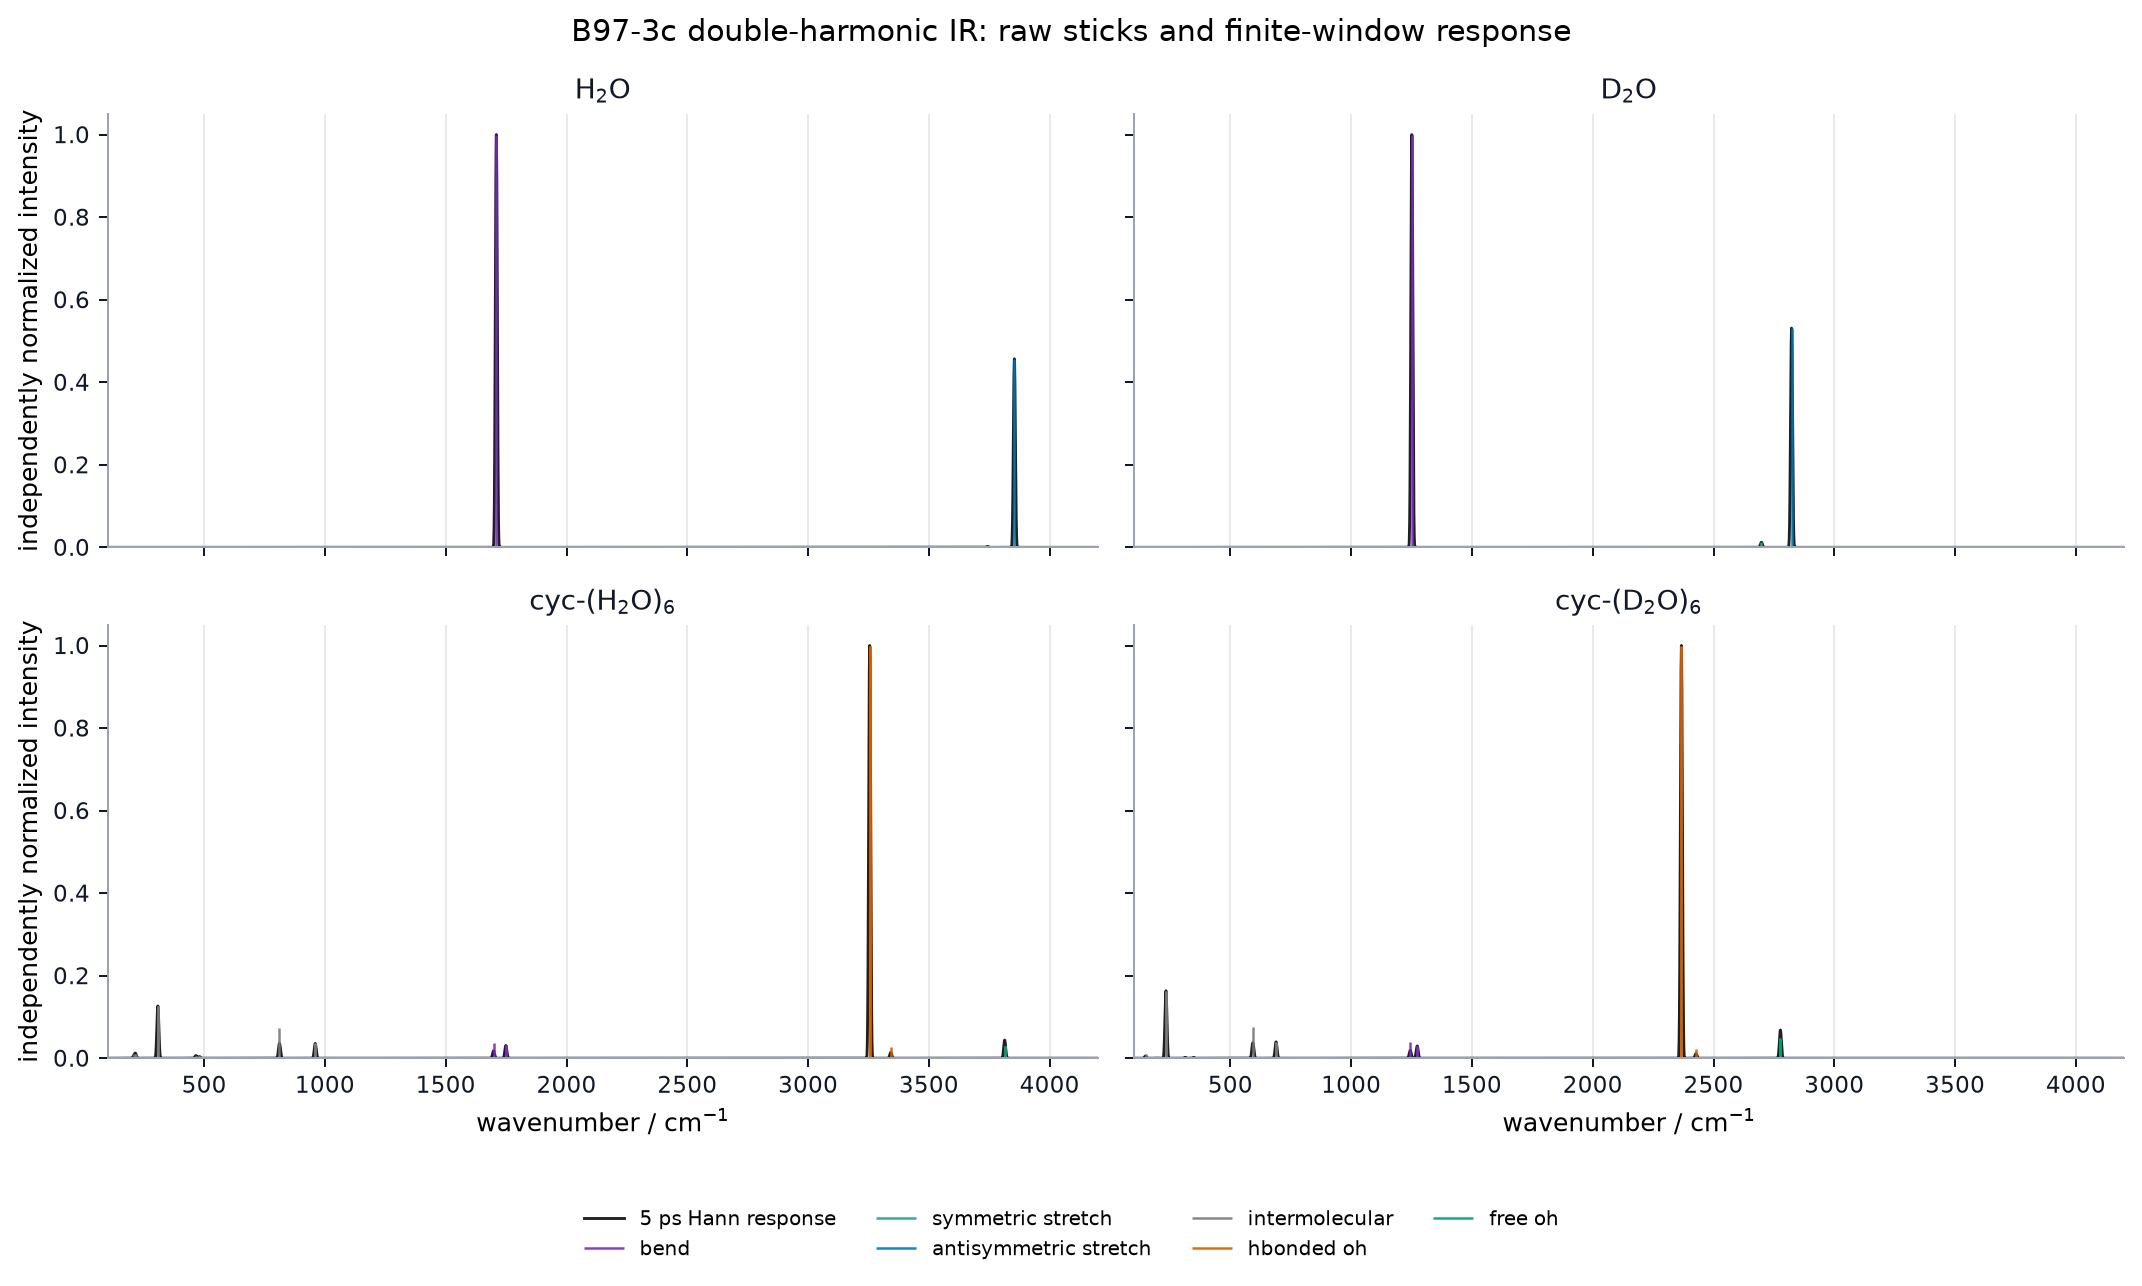


<aside role="note" aria-label="BOUNDARY" style="max-width:880px;margin:14px 0;padding:13px 16px;border:1px solid #9A3412;border-left-width:5px;border-radius:12px;background:#FFEDD5;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="color:#9A3412;font-size:12px;font-weight:800;letter-spacing:0.07em;margin-bottom:5px;">BOUNDARY</div><div style="color:#111827;font-size:14px;line-height:1.55;">Double-harmonic DFT has no overtones, finite-temperature rearrangement, or nuclear quantum dynamics. Compare band regions and controlled mass mapping—not one-to-one peak equality.</div></aside>


In [ ]:
reference_dirs = {"H2O": "h2o", "D2O": "d2o", "(H2O)6": "h6", "(D2O)6": "d6"}
references = {
    label: load_psi4_b973c_ir_artifact(REFERENCE_ROOT / directory)
    for label, directory in reference_dirs.items()
}
print("B97-3c reference preflight: PASS")
print("engine:", references["H2O"].engine_version)
print("method:", references["H2O"].manifest["model_chemistry"])


In [ ]:
run_progress = NotebookProgress(
    title="Prepare and run the full NVT → NVE trajectory",
    total=TOTAL_DYNAMICS_STEPS,
    unit="steps",
    message="Preparing isotope masses, integrators, and hooks",
)
batch = relaxed_batch.clone()
batch["status"] = torch.zeros(batch.num_graphs, 1, dtype=torch.long, device=DEVICE)

# Paired random draws; different masses then generate the physical velocity scale.
for graph, seed in zip(range(batch.num_graphs), (101, 101, 202, 202), strict=True):
    start, stop = ptr[graph], ptr[graph + 1]
    local_idx = torch.zeros(stop - start, dtype=torch.int32, device=DEVICE)
    initialize_velocities(
        batch.velocities[start:stop],
        batch.atomic_masses[start:stop],
        torch.tensor([TEMPERATURE_K], device=DEVICE, dtype=batch.positions.dtype),
        local_idx,
        random_seed=seed,
        remove_com=True,
        remove_rotations=True,
        rescale=True,
        positions=batch.positions[start:stop],
    )

ir_hook = PredictedChargeIRHook(
    warmup_steps=WARMUP_STEPS,
    n_steps=PRODUCTION_STEPS,
    dt_fs=DT_FS,
    compile_reducer=True,
)
nvt = NVTLangevin(
    model=model,
    dt=DT_FS,
    temperature=TEMPERATURE_K,
    friction=0.01,
    random_seed=303,
    n_steps=WARMUP_STEPS,
    # FusedStage otherwise supplies its default force-convergence migration.
    # This never-passing criterion makes the declared step count the sole
    # NVT → NVE transition condition.
    convergence_hook=ConvergenceHook.from_fmax(threshold=-1.0),
)
nve = NVE(model=model, dt=DT_FS)
dynamics = nvt + nve
assert isinstance(dynamics, FusedStage)

for neighbor_hook in model.make_neighbor_hooks():
    dynamics.register_hook(neighbor_hook)
dynamics.register_hook(NaNDetectorHook(frequency=100, extra_keys=["velocities"]))
dynamics.register_hook(ir_hook)
run_progress_hook: Hook = NotebookStageProgressHook(
    run_progress, frequency=1_000, label="NVT + NVE"
)
dynamics.register_hook(run_progress_hook)

md_log_hook = LoggingHook(
    backend="csv",
    log_path=OUTPUT_DIR / "water_ir_dynamics_log.csv",
    frequency=1_000,
)
dynamics.register_hook(md_log_hook)

print("stages:", type(nvt).__name__, "+", type(nve).__name__)
print("fused as:", type(dynamics).__name__)
print("exact updates:", WARMUP_STEPS, "+", PRODUCTION_STEPS, "=", TOTAL_DYNAMICS_STEPS)
print("recorder stage/frequency:", ir_hook.stage, ir_hook.frequency)
print("NaN/Inf safety check: every 100 steps; workload is never shortened")


In [ ]:
torch.cuda.synchronize()
t0 = perf_counter()
final_batch = dynamics.run(batch, n_steps=TOTAL_DYNAMICS_STEPS)
torch.cuda.synchronize()
elapsed_s = perf_counter() - t0
trajectory = ir_hook.result()
stage_counts = ir_hook.stage_counts
run_progress.complete(f"{TOTAL_DYNAMICS_STEPS:,} updates complete in {elapsed_s / 60:.2f} min")

assert trajectory.dipoles_e_angstrom.shape == (PRODUCTION_STEPS, 4, 3)
assert trajectory.positions_angstrom.shape == (PRODUCTION_STEPS, 42, 3)
assert stage_counts == {
    "status_0_warmup_steps": WARMUP_STEPS,
    "status_1_production_steps": PRODUCTION_STEPS,
}
print("captured:", trajectory.dipoles_e_angstrom.shape, "dipoles")
print("positions:", trajectory.positions_angstrom.shape)
print("stage route:", stage_counts)
print("shared model calls by stage design:", 1 + TOTAL_DYNAMICS_STEPS)


In [ ]:
trajectory_path = OUTPUT_DIR / "water_ir_trajectory.npz"
trajectory_manifest = save_ir_trajectory(trajectory_path, trajectory, labels)
structure_manifest = write_structure_artifacts(
    OUTPUT_DIR,
    seed_batch=unrelaxed_batch,
    relaxed_batch=relaxed_batch,
    trajectory=trajectory,
    graph_index=2,
    graph_label="(H2O)6",
    stride=100,
)
display(pd.Series(trajectory_manifest, name="raw trajectory").to_frame())
display(callout(
    "All 50,000 production frames and viewer-ready seed/relaxed/trajectory structures were saved before any reporting gate.",
    kind="result",
    result_state="pass",
))


In [ ]:
# Analysis restart: this reloads the complete, validated raw artifact.
# It is not a claim of bitwise mid-integrator continuation.
trajectory_sha_before = sha256_file(trajectory_path)
trajectory, reloaded_labels = load_ir_trajectory(trajectory_path)
trajectory_sha_after = sha256_file(trajectory_path)
assert reloaded_labels == labels
assert trajectory_sha_after == trajectory_sha_before == trajectory_manifest["sha256"]

display(callout(
    f"Analysis restart verified: {trajectory.positions_angstrom.shape[0]:,} complete frames, SHA-256 {trajectory_sha_after[:16]}…",
    kind="result",
    result_state="pass",
))


<section role="region" aria-labelledby="alchemi-stage-6-heading" style="max-width:880px;margin:18px 0;background:#FFFFFF;border:1px solid #D1D5DB;border-radius:12px;overflow:hidden;box-shadow:0 1px 2px rgba(0,0,0,0.05);font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div role="progressbar" aria-label="Notebook stage" aria-valuemin="1" aria-valuemax="6" aria-valuenow="6" aria-valuetext="STAGE 6 OF 6" style="height:6px;background:#E5E7EB;overflow:hidden;"><div aria-hidden="true" style="height:100%;width:100.00%;background:#76B900;"></div></div><div style="padding:16px 18px 17px;"><div style="display:flex;align-items:center;justify-content:space-between;gap:12px;flex-wrap:wrap;margin-bottom:9px;"><span style="color:#4B5563;font-size:12px;font-weight:700;letter-spacing:0.08em;">STAGE 6 OF 6</span><span style="display:inline-block;padding:3px 9px;border-radius:999px;background:#F3F4F6;color:#374151;font-size:12px;font-weight:750;letter-spacing:0.04em;">STAGE</span></div><h2 id="alchemi-stage-6-heading" style="color:#111827;font-size:21px;font-weight:750;line-height:1.25;margin:0 0 7px;">Decide what survived</h2><div style="color:#4B5563;font-size:14px;line-height:1.55;"><strong style="color:#111827;">Outcome:</strong> Turn the complete trajectory into spectra only after charge, temperature, covalent-integrity, and topology checks are visible.</div></div></section>

<aside role="note" aria-label="BEFORE YOU RUN" style="max-width:880px;margin:14px 0;padding:13px 16px;border:1px solid #075985;border-left-width:5px;border-radius:12px;background:#E0F2FE;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="color:#075985;font-size:12px;font-weight:800;letter-spacing:0.07em;margin-bottom:5px;">BEFORE YOU RUN</div><div style="color:#111827;font-size:14px;line-height:1.55;">The full trajectory is already on disk. A failed comparison gate withholds that claim; it never deletes or shortens the calculation.</div></aside>

- Charge is checked on every saved frame.
- Temperature uses Toolkit's 3N convention and the integrator masses.
- Compared trajectories must have mean NVE temperatures within 20%.
- Both hexamers must remain connected with assigned O–H distances below 1.25 Å.
- Cyclic-DFT overlays require the initial directed six-water ring in every frame.
- The 1 meV atom⁻¹ energy-excursion line is an advisory, not a stopping rule.


In [ ]:
charge_error = np.max(np.abs(trajectory.charge_sums_e), axis=0)
integrity = [
    cluster_integrity(
        trajectory,
        graph,
        oxygen_cutoff_angstrom=OXYGEN_CONNECTIVITY_CUTOFF_A,
        h_acceptor_cutoff_angstrom=HBOND_H_ACCEPTOR_CUTOFF_A,
        oo_cutoff_angstrom=HBOND_OO_CUTOFF_A,
        hbond_angle_cutoff_deg=HBOND_ANGLE_CUTOFF_DEG,
    )
    for graph in (2, 3)
]
integrity_table = pd.DataFrame(integrity, index=labels[2:])

KB_EV_K = 8.617333262145e-5
atoms_per_graph = np.diff(trajectory.batch_ptr)
nve_temperature = (
    2.0 * trajectory.kinetic_energies_eV
    / (3.0 * atoms_per_graph[None, :] * KB_EV_K)
)

time_ps = np.arange(trajectory.positions_angstrom.shape[0]) * trajectory.dt_fs / 1000.0
energy_drift = []
energy_excursion = []
for graph, atom_count in enumerate(atoms_per_graph):
    delta_eV = (
        trajectory.total_energies_eV[:, graph]
        - trajectory.total_energies_eV[0, graph]
    )
    slope_eV_ps = np.polyfit(time_ps, delta_eV, 1)[0]
    energy_drift.append(1000.0 * slope_eV_ps / atom_count)
    energy_excursion.append(1000.0 * np.max(np.abs(delta_eV)) / atom_count)

diagnostic_table = pd.DataFrame({
    "system": labels,
    "NVE_start_T_3N_K": nve_temperature[0],
    "NVE_mean_T_3N_K": nve_temperature.mean(axis=0),
    "max_charge_error_e": charge_error,
    "energy_drift_meV_atom_ps": energy_drift,
    "max_energy_excursion_meV_atom": energy_excursion,
}).set_index("system")
display(diagnostic_table.round(5))
display(integrity_table)

cluster_intact = bool(
    (integrity_table["max_oxygen_components"] == 1).all()
    and (integrity_table["max_OH_angstrom"] < COVALENT_OH_CUTOFF_A).all()
)
cluster_dft_comparison_valid = bool(
    integrity_table["all_frames_initial_ring"].all()
)
energy_within_advisory = bool(
    np.max(energy_excursion) <= ENERGY_EXCURSION_ADVISORY_MEV_PER_ATOM
)
print("hexamer intact  :", "PASS" if cluster_intact else "FAIL")
print(
    "initial ring   :",
    "PASS"
    if cluster_dft_comparison_valid
    else "PERSISTENCE GATE FAILED — cyclic DFT overlay withheld",
)
print(
    "energy advisory:",
    "within reporting line" if energy_within_advisory else "review trajectory",
)
if not cluster_intact:
    raise RuntimeError("Hexamer fragmented or an assigned O–H bond broke")

gate_message = (
    "Both hexamers stayed connected with intact assigned O–H bonds. "
    + (
        "The initial cyclic topology also persisted in every frame."
        if cluster_dft_comparison_valid
        else "The initial ring changed, so cyclic-DFT comparisons will be withheld."
    )
)
display(callout(
    gate_message,
    kind="result",
    result_state="pass" if cluster_dft_comparison_valid else "withheld",
))


In [ ]:
topology_timelines = {
    label: topology_time_series(
        trajectory,
        graph,
        h_acceptor_cutoff_angstrom=HBOND_H_ACCEPTOR_CUTOFF_A,
        oo_cutoff_angstrom=HBOND_OO_CUTOFF_A,
        hbond_angle_cutoff_deg=HBOND_ANGLE_CUTOFF_DEG,
    )
    for graph, label in ((2, "(H2O)6"), (3, "(D2O)6"))
}
topology_figure, _ = plot_topology_timeline(topology_timelines)
topology_figure.savefig(
    OUTPUT_DIR / "water_ir_topology_timeline.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


### Predicted-charge IR proxy

The total cluster dipole is not split into molecule-by-molecule pieces: intermolecular cross-correlations belong in the spectrum. Fixed comparison windows are:

- H₂O: 2800–4000 cm⁻¹
- D₂O: 2000–3100 cm⁻¹

These are region summaries, not bond-specific stretch assignments.


In [ ]:
OH_REGION_WINDOWS_CM1 = {"H": (2800.0, 4000.0), "D": (2000.0, 3100.0)}
spectrum_analysis = ir_spectrum_metrics(
    trajectory.dipoles_e_angstrom,
    labels,
    dt_fs=trajectory.dt_fs,
    segment_time_fs=5000.0,
    overlap=0.5,
    region_windows_cm1=OH_REGION_WINDOWS_CM1,
)
spectra = spectrum_analysis.spectra
metrics = spectrum_analysis.metrics

gate_analysis = ir_comparison_gate_table(
    metrics,
    nve_temperature,
    labels,
    pair_temperature_relative_tolerance=PAIR_TEMPERATURE_RELATIVE_TOLERANCE,
    cluster_topology_gate=cluster_dft_comparison_valid,
)
comparisons = gate_analysis.table

display(metrics.round(2))
display(comparisons.round(3))
reported_count = int(comparisons["reported"].sum())
display(callout(
    f"{reported_count} of {len(comparisons)} comparisons passed the declared thermal and topology gates.",
    kind="result",
    result_state="pass" if reported_count == len(comparisons) else "withheld",
))


### Compare to the harmonic endpoint

- B97-3c/def2-mTZVP frequencies and dipole derivatives are checksummed.
- Raw sticks stay visible; the smooth lane adds only the known 5 ps Hann response.
- MD and DFT lanes are normalized independently. Compare regions, not absolute intensity.


In [ ]:
reference_analysis = reference_comparison_metrics(
    spectra,
    references,
    labels,
    dt_fs=trajectory.dt_fs,
    segment_time_fs=5000.0,
    region_windows_cm1=OH_REGION_WINDOWS_CM1,
    cluster_topology_gate=cluster_dft_comparison_valid,
)
reference_comparisons = reference_analysis.comparisons
reference_metrics = reference_analysis.metrics
display(reference_metrics.round(1))
print("reference engine:", references["H2O"].engine_version)
print("reference method:", references["H2O"].manifest["model_chemistry"])


In [ ]:
mode_mapping = h_to_d_mode_mapping_table(
    references,
    coarse_mass_path_steps=65,
    fine_mass_path_steps=129,
    degeneracy_tolerance_cm1=2.0,
    covalent_oh_cutoff_angstrom=COVALENT_OH_CUTOFF_A,
    h_acceptor_cutoff_angstrom=HBOND_H_ACCEPTOR_CUTOFF_A,
    oo_cutoff_angstrom=HBOND_OO_CUTOFF_A,
    hbond_angle_cutoff_deg=HBOND_ANGLE_CUTOFF_DEG,
)
mode_map_table = mode_mapping.table
display(mode_map_table.round({
    "H_center_cm-1": 1,
    "H_span_cm-1": 1,
    "D_center_cm-1": 1,
    "D_span_cm-1": 1,
    "H_over_D_center": 3,
    "H_IR_sum_km_mol": 1,
    "D_IR_sum_km_mol": 1,
    "mapping_overlap": 4,
    "bend_fraction": 3,
    "hbonded_OH_fraction": 3,
    "free_OH_fraction": 3,
    "intermolecular_fraction": 3,
}))
print(
    "Degenerate rows are mapped as subspaces; 65- and 129-step mass paths agree."
)
display(callout(
    "H→D mode mapping is stable to the finer mass path; ambiguous degenerate vectors remain grouped as subspaces.",
    kind="result",
    result_state="pass",
))


In [ ]:
ir_figure, _ = plot_md_dft_comparison(
    labels,
    spectra,
    reference_comparisons,
    wavenumber_limits_cm1=(500.0, 4200.0),
)
ir_figure.savefig(
    OUTPUT_DIR / "water_ir_dft_mapping.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


In [ ]:
diagnostic_table.to_csv(OUTPUT_DIR / "water_ir_diagnostics.csv")
metrics.to_csv(OUTPUT_DIR / "water_ir_metrics.csv")
integrity_table.to_csv(OUTPUT_DIR / "water_ir_topology.csv")
comparisons.to_csv(OUTPUT_DIR / "water_ir_comparisons.csv")
reference_metrics.to_csv(OUTPUT_DIR / "water_ir_dft_comparison.csv")
mode_map_table.to_csv(OUTPUT_DIR / "water_ir_h_to_d_mode_map.csv", index=False)
dimer_table.to_csv(OUTPUT_DIR / "water_dimer_ablation.csv", index=False)
ablation_mae.to_csv(OUTPUT_DIR / "water_dimer_ablation_mae.csv", header=True)
cold_warm.to_csv(OUTPUT_DIR / "water_batch_first_warm_calls.csv", index=False)
crossover.to_csv(OUTPUT_DIR / "water_batch_cpu_gpu_crossover.csv", index=False)
pd.DataFrame(layout_result["timings"]).to_csv(
    OUTPUT_DIR / "water_batch_layouts.csv", index=False
)
for label, timeline in topology_timelines.items():
    slug = "h6" if label == "(H2O)6" else "d6"
    timeline.to_csv(OUTPUT_DIR / f"water_ir_{slug}_topology_timeline.csv", index=False)

spectrum_table = pd.DataFrame({"wavenumber_cm-1": next(iter(spectra.values()))[0]})
for label, (_, intensity) in spectra.items():
    spectrum_table[f"{label}_PSD_arb"] = intensity
spectrum_table.to_csv(OUTPUT_DIR / "water_ir_spectra.csv", index=False)

run_manifest = write_water_run_manifest(
    OUTPUT_DIR,
    provenance={
        "run_id": RUN_ID,
        "slurm_job_id": os.environ.get("SLURM_JOB_ID"),
        "gpu": torch.cuda.get_device_name(DEVICE),
        "torch": torch.__version__,
        "aimnet": metadata.version("aimnet"),
        "toolkit_core_commit": installed_pins["Core"],
        "toolkit_ops_commit": installed_pins["Ops"],
        "checkpoint_source": MODEL_CHECKPOINT,
        "checkpoint_sha256": model_card["checkpoint_sha256"],
        "d3_parameter_file_sha256": D3_PARAMETER_SHA256,
        "checkpoint_override": checkpoint_is_override,
        "notebook_sha256": sha256_file(PART_DIR / "alchemi-water-ir.ipynb"),
        "dimer_reference_manifest_sha256": sha256_file(
            REFERENCE_ROOT / "water_dimer_b97_3c" / "manifest.json"
        ),
        "harmonic_reference_sha256s": {
            label: sha256_file(REFERENCE_ROOT / directory / "manifest.json")
            for label, directory in reference_dirs.items()
        },
    },
    settings={
        "model": "AIMNet residual + predicted-charge all-pairs Coulomb + pairwise D3(BJ)",
        "electrostatics": "simple nonperiodic all-pairs 1/r; no cutoff",
        "d3_cutoff_A": D3_CUTOFF_A,
        "d3_parameters": d3_params,
        "compile_mode": "default Torch compile on the fixed 42-atom IR batch",
        "neighbor_skin_A": NEIGHBOR_SKIN_A,
        "temperature_K": TEMPERATURE_K,
        "dt_fs": DT_FS,
        "warmup_steps": WARMUP_STEPS,
        "production_steps": PRODUCTION_STEPS,
        "spectrum_segment_time_fs": 5000.0,
        "spectrum_overlap": 0.5,
        "spectrum_windows_cm1": OH_REGION_WINDOWS_CM1,
        "pair_temperature_relative_tolerance": PAIR_TEMPERATURE_RELATIVE_TOLERANCE,
        "oxygen_connectivity_cutoff_A": OXYGEN_CONNECTIVITY_CUTOFF_A,
        "covalent_OH_cutoff_A": COVALENT_OH_CUTOFF_A,
        "hbond_H_acceptor_cutoff_A": HBOND_H_ACCEPTOR_CUTOFF_A,
        "hbond_OO_cutoff_A": HBOND_OO_CUTOFF_A,
        "hbond_angle_cutoff_deg": HBOND_ANGLE_CUTOFF_DEG,
        "energy_excursion_advisory_meV_atom": ENERGY_EXCURSION_ADVISORY_MEV_PER_ATOM,
    },
    gates={
        "residual_serial_batch_max_abs_eV": serial_batch_error,
        "full_serial_batch_max_abs_eV": full_pipeline_parity_error,
        "component_closure_max_abs_eV": component_closure_error,
        "official_calculator_parity": parity_errors,
        "analytic_coulomb": analytic_coulomb_errors,
        "compiled_ir_eager_parity": compiled_ir_eager_parity,
        "compiled_ir_repeat_parity": compiled_ir_repeat_parity,
        "finite_difference_force_reference_eV_A": fd_force,
        "finite_difference_force_pipeline_eV_A": model_force,
        "finite_difference_force_abs_error_eV_A": fd_force_error,
        "cluster_integrity_passed": cluster_intact,
        "initial_ring_persisted_all_frames": cluster_dft_comparison_valid,
        "energy_excursion_within_advisory": energy_within_advisory,
        "reported_comparisons": comparisons["reported"].to_dict(),
        "fused_stage_route_counts": stage_counts,
    },
)

print("saved:")
for path in sorted(OUTPUT_DIR.glob("water_*")):
    print(" -", path.relative_to(ROOT))
display(callout(
    f"Raw trajectory, Toolkit Zarr replay, benchmarks, gates, spectra, and checksummed run manifest are in {OUTPUT_DIR.relative_to(ROOT)}.",
    kind="result",
    result_state="pass",
))


### Try it — one geometry you choose

Change one O–O distance, then reuse the same public Toolkit path. This reports the composed model only; no DFT value is invented for a geometry that was not computed in the reference set.


<aside role="note" aria-label="BEFORE YOU RUN" style="max-width:880px;margin:14px 0;padding:13px 16px;border:1px solid #075985;border-left-width:5px;border-radius:12px;background:#E0F2FE;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="color:#075985;font-size:12px;font-weight:800;letter-spacing:0.07em;margin-bottom:5px;">BEFORE YOU RUN</div><div style="color:#111827;font-size:14px;line-height:1.55;">Edit TRY_OO_DISTANCE_A, predict whether the interaction becomes more or less attractive, then run the cell.</div></aside>


In [ ]:
TRY_OO_DISTANCE_A = 3.30
trial_progress = NotebookProgress(
    title="Editable composed-model call", total=1, unit="geometry"
)
trial_dimer = make_water_dimer(TRY_OO_DISTANCE_A)
trial_graphs = [trial_dimer, trial_dimer[:3], trial_dimer[3:]]
for atoms in trial_graphs:
    atoms.info["charge"] = 0

trial_data = [
    AtomicData.from_atoms(atoms, device=DEVICE, dtype=torch.float64)
    for atoms in trial_graphs
]
trial_batch = Batch.from_data_list(trial_data, device=DEVICE)
compute_neighbors(trial_batch, config=eager_model.model_config.neighbor_config)
trial_progress.update(
    done=0,
    message="evaluating; a new graph shape may compile on its first call",
)
trial_outputs = eager_model(trial_batch)
trial_energy = trial_outputs["energy"].detach().cpu().reshape(-1).numpy()
trial_interaction_kJ_mol = (
    trial_energy[0] - trial_energy[1] - trial_energy[2]
) * 96.48533212331002
trial_progress.complete("editable AB/A/B interaction evaluated")

display(callout(
    f"Observed composed-model interaction at {TRY_OO_DISTANCE_A:.2f} Å: {trial_interaction_kJ_mol:.2f} kJ/mol.",
    kind="result",
    result_state="observed",
))


### What you can now do

- Build and inspect `AtomicData` and `Batch` directly.
- Decide between serial, mixed, and homogeneous-bucket execution from measured data.
- Compose an AIMNet residual with explicit finite-system all-pairs Coulomb and D3 terms.
- Relax and propagate four systems with one Toolkit model call per step.
- Reuse predicted charges for a total-dipole IR proxy without a second inference pass.
- Separate a complete trajectory from claims that survive thermal and topology gates.


<aside role="note" aria-label="RESULT — PASS" style="max-width:880px;margin:14px 0;padding:13px 16px;border:1px solid #365314;border-left-width:5px;border-radius:12px;background:#ECFCCB;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;"><div style="color:#365314;font-size:12px;font-weight:800;letter-spacing:0.07em;margin-bottom:5px;">RESULT — PASS</div><div style="color:#111827;font-size:14px;line-height:1.55;">Part 1 ends with reusable artifacts and an editable Toolkit call—not a hidden application wrapper.</div></aside>


## References and licenses

- [AIMNet2-2025 B97-3c model card](https://huggingface.co/isayevlab/aimnet2-2025) — ensemble member 0, MIT license; external D3(BJ) and selectable simple/DSF/Ewald/PME electrostatics declared by the model metadata.
- Anstine, Zubatyuk, Isayev, [*AIMNet2*](https://doi.org/10.1039/D4SC08572H), *Chemical Science* (2025).
- Brandenburg *et al.*, [B97-3c](https://doi.org/10.1063/1.5012601), *J. Chem. Phys.* **148**, 064104 (2018).
- Howard, Enyard, Tschumper, [37-functional water-cluster frequency benchmark](https://doi.org/10.1063/1.4936654), *J. Chem. Phys.* **143**, 214103 (2015).
- Howard and Tschumper, [near-CCSD(T) water-cluster frequencies](https://doi.org/10.1021/acs.jctc.5b00225), *J. Chem. Theory Comput.* **11**, 2126–2136 (2015).
- Losada and Leutwyler, [water-hexamer harmonic frequencies and intensities](https://doi.org/10.1063/1.1487371), *J. Chem. Phys.* **117**, 2003–2016 (2002), literature context for MP2 harmonic spectra—not a numerical validation gate here.
- Wang and Bowman, [anharmonic water-hexamer IR](https://doi.org/10.1021/jz400414a), *J. Phys. Chem. Lett.* **4**, 1104–1108 (2013).
- Thomas, Brehm, Fligg, Vöhringer, and Kirchner, [computing vibrational spectra from molecular dynamics](https://doi.org/10.1039/C3CP44302G), *Phys. Chem. Chem. Phys.* **15**, 6608–6622 (2013).
- Fennell and Gezelter, [DSF electrostatics](https://doi.org/10.1063/1.2206581), *J. Chem. Phys.* **124**, 234104 (2006).
- The live `DFTD3ModelWrapper` is NVIDIA Toolkit code under Apache-2.0; this repository does not bundle a prewarmed D3 parameter cache.
- The separate reference environment uses [Psi4](https://psicode.org/) (LGPL-3.0), `dftd3-python`, and `mctc-gcp` (LGPL-3.0-or-later). The bundled arrays are generated tutorial outputs, not copied literature tables.
- NVIDIA [ALCHEMI Toolkit](https://github.com/NVIDIA/nvalchemi-toolkit) and [Toolkit-Ops](https://github.com/NVIDIA/nvalchemi-toolkit-ops) — Apache-2.0.

The cyclic hexamer seed is generated in this notebook and relaxed live; no external coordinate file is redistributed.
